# Lake Area / Lakeside Analysis

This notebook investigates the lake-side files in `stat_analysis/data`.

It checks:
- `*_lake.gpkg`
- `*_area_lake.gpkg`
- `*_area_lake_polygon.shp`

It tells you:
- which files load
- which files are lines or polygons
- whether shapefile sidecars are missing
- whether area can be calculated directly
- whether closed line files can be polygonized
- which source is best per map

Set `SAVE_OUTPUTS = True` to save CSV/PNG outputs.

In [25]:
from pathlib import Path
import re
import unicodedata

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.ops import polygonize

In [26]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [27]:
REPO_ROOT = Path("../..")

DATA_DIR = REPO_ROOT / "stat_analysis" / "data"
if not DATA_DIR.exists():
    DATA_DIR = Path("../stat_analysis/data")

OUTPUT_ROOT = REPO_ROOT / "stat_analysis" / "output" / "lake_area_analysis"
if not OUTPUT_ROOT.parent.exists():
    OUTPUT_ROOT = Path("../stat_analysis/output/lake_area_analysis")

TARGET_EPSG = 2056
SAVE_OUTPUTS = True

MAP_ORDER = {
    "melotte": 1721,
    "berney": 1831,
    "renove": 1888,
    "1937": 1937,
    "1959": 1959,
    "contemporain": 2021,
}

MAP_LABELS = {
    "melotte": "Melotte (1721)",
    "berney": "Berney (1831)",
    "renove": "Rénové (1888)",
    "1937": "1937",
    "1959": "1959",
    "contemporain": "Contemporary (2021)",
}

COLORS = {
    "line": "#007AFF",
    "polygon": "#34C759",
    "polygonized": "#FF9F0A",
}

In [28]:
print("DATA_DIR:", DATA_DIR, DATA_DIR.exists())
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("SAVE_OUTPUTS:", SAVE_OUTPUTS)

DATA_DIR: ../../stat_analysis/data True
OUTPUT_ROOT: ../../stat_analysis/output/lake_area_analysis
SAVE_OUTPUTS: True


## Helper functions

In [29]:
def normalize_text(value):
    if not isinstance(value, str):
        return ""
    value = value.lower().strip()
    return "".join(
        c for c in unicodedata.normalize("NFD", value)
        if unicodedata.category(c) != "Mn"
    )


def infer_map_key(filename):
    lower = normalize_text(filename)
    for key in MAP_ORDER:
        if key in lower:
            return key
    match = re.search(r"\d{4}", lower)
    return match.group() if match else None


def sort_key_for_map(map_key):
    if map_key in MAP_ORDER:
        return MAP_ORDER[map_key]
    if str(map_key).isdigit():
        return int(map_key)
    return 9999


def label_for_map(map_key):
    return MAP_LABELS.get(map_key, str(map_key))


def is_save_table(df, path):
    if SAVE_OUTPUTS:
        path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(path, index=False)
        print("Saved:", path)


def is_savefig(path):
    if SAVE_OUTPUTS:
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, dpi=200, bbox_inches="tight")
        print("Saved:", path)


def is_lake_candidate(path):
    lower = normalize_text(path.name)
    return path.suffix.lower() in {".gpkg", ".geojson", ".shp"} and "lake" in lower


def load_layer(path):
    gdf = gpd.read_file(path)

    if gdf.crs is None:
        print(f"WARNING: Missing CRS for {path.name}; assuming EPSG:2056")
        gdf = gdf.set_crs(epsg=2056)

    gdf = gdf.to_crs(epsg=TARGET_EPSG)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    gdf["geometry"] = gdf.geometry.make_valid()

    return gdf


def layer_kind(path):
    name = normalize_text(path.name)
    if "polygon" in name:
        return "polygon_shp"
    if "area_lake" in name:
        return "area_lake"
    return "lake"


def shapefile_sidecar_status(shp_path):
    required = [".shp", ".shx", ".dbf", ".prj"]
    return pd.DataFrame([
        {
            "file": shp_path.with_suffix(s).name,
            "exists": shp_path.with_suffix(s).exists(),
            "path": str(shp_path.with_suffix(s)),
        }
        for s in required
    ])


def polygonize_line_layer(gdf):
    linework = gdf.geometry.union_all()
    polygons = list(polygonize(linework))
    if not polygons:
        return gpd.GeoDataFrame(geometry=[], crs=gdf.crs)
    out = gpd.GeoDataFrame(geometry=polygons, crs=gdf.crs)
    out["area_m2"] = out.geometry.area
    out["area_ha"] = out["area_m2"] / 10_000
    return out

In [30]:
print("DATA_DIR:", DATA_DIR, DATA_DIR.exists())
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("SAVE_OUTPUTS:", SAVE_OUTPUTS)

DATA_DIR: ../../stat_analysis/data True
OUTPUT_ROOT: ../../stat_analysis/output/lake_area_analysis
SAVE_OUTPUTS: True


## 1. Inventory of lake-side files

In [31]:
lake_files = sorted([p for p in DATA_DIR.glob("*") if is_lake_candidate(p)])

rows = []
for path in lake_files:
    map_key = infer_map_key(path.name)
    row = {
        "file": path.name,
        "kind": layer_kind(path),
        "suffix": path.suffix,
        "map_key": map_key,
        "map_label": label_for_map(map_key),
        "load_status": "not tried",
        "rows": None,
        "crs": None,
        "geometry_types": None,
        "columns": None,
        "error": None,
    }

    try:
        gdf = gpd.read_file(path)
        row.update({
            "load_status": "ok",
            "rows": len(gdf),
            "crs": str(gdf.crs),
            "geometry_types": ", ".join(gdf.geom_type.value_counts().index.astype(str)),
            "columns": ", ".join(gdf.columns.astype(str)),
        })
    except Exception as exc:
        row.update({"load_status": "failed", "error": str(exc)})

    rows.append(row)

lake_inventory = pd.DataFrame(rows).sort_values(
    ["map_key", "kind", "file"],
    key=lambda s: s.map(sort_key_for_map) if s.name == "map_key" else s,
)

display(lake_inventory)
is_save_table(lake_inventory, OUTPUT_ROOT / "tables" / "lake_file_inventory.csv")

,file,kind,suffix,map_key,map_label,load_status,rows,crs,geometry_types,columns,error
12,melotte_area_lake.gpkg,area_lake,.gpkg,melotte,Melotte (1721),ok,2,EPSG:2056,MultiLineString,"id, geometry",None
14,melotte_lake.gpkg,lake,.gpkg,melotte,Melotte (1721),ok,2,EPSG:2056,MultiLineString,"id, geometry",None
13,melotte_area_lake_polygon.shp,polygon_shp,.shp,melotte,Melotte (1721),ok,1,None,Polygon,geometry,None
6,berney_area_lake.gpkg,area_lake,.gpkg,berney,Berney (1831),ok,1,EPSG:2056,MultiLineString,"id, geometry",None
8,berney_lake.gpkg,lake,.gpkg,berney,Berney (1831),ok,1,EPSG:2056,MultiLineString,"id, geometry",None
7,berney_area_lake_polygon.shp,polygon_shp,.shp,berney,Berney (1831),ok,1,None,Polygon,geometry,None
15,renove_area_lake.gpkg,area_lake,.gpkg,renove,Rénové (1888),ok,1,EPSG:2056,MultiLineString,"id, geometry",None
17,renove_lake.gpkg,lake,.gpkg,renove,Rénové (1888),ok,1,EPSG:2056,MultiLineString,"id, geometry",None
16,renove_area_lake_polygon.shp,polygon_shp,.shp,renove,Rénové (1888),ok,1,None,Polygon,geometry,None
0,1937_area_lake.gpkg,area_lake,.gpkg,1937,1937,ok,3,EPSG:21781,MultiLineString,"id, geometry",None


Saved: ../../stat_analysis/output/lake_area_analysis/tables/lake_file_inventory.csv


## 2. Check shapefile sidecars

In [32]:
polygon_shps = [p for p in lake_files if p.suffix.lower() == ".shp" and "polygon" in normalize_text(p.name)]

for shp in polygon_shps:
    print("\n" + "=" * 80)
    print(shp.name)
    display(shapefile_sidecar_status(shp))


1937_area_lake_polygon.shp


,file,exists,path
0,1937_area_lake_polygon.shp,True,../../stat_analysis/data/1937_area_lake_polygon.shp
1,1937_area_lake_polygon.shx,True,../../stat_analysis/data/1937_area_lake_polygon.shx
2,1937_area_lake_polygon.dbf,False,../../stat_analysis/data/1937_area_lake_polygon.dbf
3,1937_area_lake_polygon.prj,False,../../stat_analysis/data/1937_area_lake_polygon.prj



1959_area_lake_polygon.shp


,file,exists,path
0,1959_area_lake_polygon.shp,True,../../stat_analysis/data/1959_area_lake_polygon.shp
1,1959_area_lake_polygon.shx,True,../../stat_analysis/data/1959_area_lake_polygon.shx
2,1959_area_lake_polygon.dbf,False,../../stat_analysis/data/1959_area_lake_polygon.dbf
3,1959_area_lake_polygon.prj,False,../../stat_analysis/data/1959_area_lake_polygon.prj



berney_area_lake_polygon.shp


...

,file,exists,path
0,contemporain_area_lake_polygon.shp,True,../../stat_analysis/data/contemporain_area_lake_polygon.shp
1,contemporain_area_lake_polygon.shx,True,../../stat_analysis/data/contemporain_area_lake_polygon.shx
2,contemporain_area_lake_polygon.dbf,False,../../stat_analysis/data/contemporain_area_lake_polygon.dbf
3,contemporain_area_lake_polygon.prj,False,../../stat_analysis/data/contemporain_area_lake_polygon.prj



melotte_area_lake_polygon.shp


,file,exists,path
0,melotte_area_lake_polygon.shp,True,../../stat_analysis/data/melotte_area_lake_polygon.shp
1,melotte_area_lake_polygon.shx,True,../../stat_analysis/data/melotte_area_lake_polygon.shx
2,melotte_area_lake_polygon.dbf,False,../../stat_analysis/data/melotte_area_lake_polygon.dbf
3,melotte_area_lake_polygon.prj,False,../../stat_analysis/data/melotte_area_lake_polygon.prj



renove_area_lake_polygon.shp


,file,exists,path
0,renove_area_lake_polygon.shp,True,../../stat_analysis/data/renove_area_lake_polygon.shp
1,renove_area_lake_polygon.shx,True,../../stat_analysis/data/renove_area_lake_polygon.shx
2,renove_area_lake_polygon.dbf,False,../../stat_analysis/data/renove_area_lake_polygon.dbf
3,renove_area_lake_polygon.prj,False,../../stat_analysis/data/renove_area_lake_polygon.prj


## 3. Load and plot each loadable lake-side layer


1937_area_lake.gpkg
Rows: 3
Geometry types:
MultiLineString    3
Name: count, dtype: int64


,id,geometry
0,0,"MULTILINESTRING ((2535880.574 1151550.365, 2535909.94 1151559.811, 2535923.866 1151560.772, 2535953.399 1151554.289, 2535994.458 1151539.402, 2535998.78 1151556.209, 2536001.301 1151563.773, 2536011.626 1151576.259, 2536020.27 1151586.223, 2536022.311 1151584.422, 2536026.993 1151587.304, 2536025.432 1151590.905, 2536039.598 1151600.75, 2536055.446 1151608.673, 2536069.132 1151614.196, 2536080.297 1151617.317, 2536140.204 1151607.713, 2536140.324 1151613.835, 2536140.324 1151619.958, 2536139.844 1151624.88, 2536149.568 1151630.763, 2536150.589 1151643.249, 2536153.23 1151649.432, 2536159.713 1151656.395, 2536160.613 1151664.198, 2536168.177 1151668.28, 2536182.523 1151674.463, 2536186.185 1151675.003, 2536190.867 1151671.041, 2536191.047 1151682.446, 2536191.587 1151689.53, 2536194.889 1151694.872, 2536200.591 1151698.114, 2536205.754 1151700.995, 2536215.898 1151709.219, 2536225.622 1151717.682, 2536237.088 1151722.004, 2536247.833 1151724.886, 2536264.64 1151728.307, 2536283.008 1151729.748, 2536308.94 1151729.028, 2536334.031 1151726.386, 2536337.633 1151729.508, 2536349.999 1151731.068, 2536361.524 1151726.747))"
1,0,"MULTILINESTRING ((2536361.526 1151726.744, 2536462.06 1151679.263, 2536476.085 1151671.361, 2536482.801 1151669.386, 2536515.198 1151649.04, 2536562.014 1151617.829, 2536567.545 1151614.47, 2536571.101 1151606.174, 2536574.459 1151603.803, 2536581.175 1151614.075, 2536587.299 1151616.841, 2536601.127 1151620.594, 2536607.053 1151623.162, 2536637.474 1151607.557, 2536690.019 1151571.407, 2536666.808 1151514.121, 2536699.105 1151500.195, 2536705.92 1151483.503, 2536720.637 1151476.49, 2536724.983 1151485.379, 2536734.563 1151509.183, 2536782.664 1151485.182, 2536814.27 1151459.897, 2536840.74 1151431.847, 2536862.074 1151405.772, 2536865.63 1151399.055, 2536874.914 1151392.932, 2536886.371 1151391.549, 2536896.248 1151396.883, 2536907.903 1151408.537, 2536931.706 1151433.328, 2536939.509 1151432.341, 2536946.028 1151437.477, 2536974.078 1151411.105, 2537018.722 1151369.622, 2537098.033 1151298.114, 2537125.491 1151270.261, 2537132.405 1151258.606, 2537132.207 1151248.137, 2537132.602 1151231.938, 2537138.923 1151203.493, 2537146.232 1151185.912, 2537147.417 1151174.455, 2537145.047 1151169.912, 2537132.602 1151157.072, 2537119.96 1151144.627, 2537108.503 1151125.466, 2537134.182 1151111.44, 2537159.072 1151099.193, 2537167.961 1151094.057, 2537182.184 1151090.106, 2537225.84 1151059.29, 2537236.705 1151043.882, 2537240.705 1151043.833, 2537242.779 1151041.413, 2537249.396 1151048.821, 2537272.953 1151028.326, 2537282.78 1151025.215, 2537292.657 1151023.734, 2537316.954 1151022.746, 2537334.239 1151025.314, 2537343.326 1151027.684, 2537352.215 1151033.117, 2537358.536 1151028.376, 2537366.042 1151039.191, 2537372.462 1151048.278, 2537374.339 1151046.796, 2537375.821 1151042.45, 2537386.29 1151037.907, 2537404.661 1151023.684, 2537418.785 1151012.721, 2537454.243 1150983.14, 2537452.465 1150981.362, 2537465.108 1150969.707, 2537486.738 1150994.152, 2537489.405 1150996.671, 2537522.344 1150966.003, 2537520.566 1150962.694, 2537521.406 1150957.805, 2537524.468 1150953.558, 2537531.727 1150952.571, 2537617.014 1150874.839, 2537686.004 1150812.319, 2537784.724 1150721.797, 2537786.847 1150720.908, 2537828.627 1150738.637, 2537851.344 1150747.724, 2537849.072 1150750.687, 2537826.849 1150760.169, 2537812.626 1150774.885, 2537794.551 1150792.762, 2537787.835 1150800.565, 2537784.675 1150807.775, 2537787.588 1150811.529, 2537776.23 1150839.233, 2537769.711 1150854.197, 2537784.181 1150889.951, 2537787.588 1150891.482, 2537784.576 1150900.569, 2537814.058 1150911.532, 2537868.579 1150931.878, 2537873.517 1150920.718, 2537881.246 1150923.162, 2537900.111 1150912.791, 2537899.716 1150909.236, 2537899.716 1150905.581, 2537901.79 1150902.816, 2537904.16 1150901.63, 2537907.025 1150901.63, 2537909.938 1150902.668, 2537913.049 1150908.248, 2537914.729 1150910.767, 2537923.42 1150913.68, 2538020.016 1150947.85

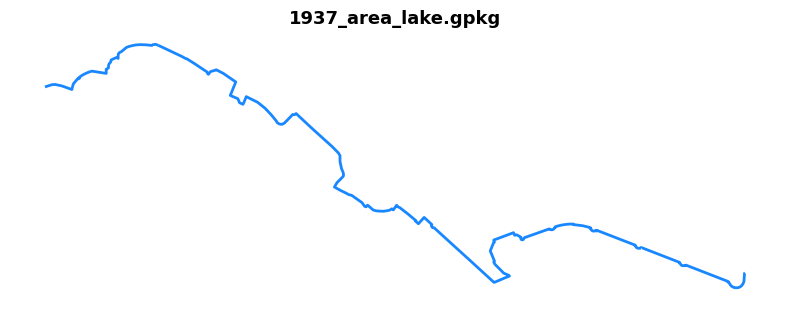


1937_area_lake_polygon.shp
Rows: 1
Geometry types:
Polygon    1
Name: count, dtype: int64


geometry
0  POLYGON ((538850.792 150761.161, 538874.776 150198.563, 535789.485 151407.992, 535880.574 151550.365, 535909.94 151559.811, 535923.866 151560.772, 535953.399 151554.289, 535994.458 151539.402, 536001.301 151563.773, 536011.626 151576.259, 536020.27 151586.223, 536022.311 151584.422, 536026.993 151587.304, 536025.432 151590.905, 536039.598 151600.75, 536055.446 151608.673, 536069.132 151614.196, 536080.297 151617.317, 536140.204 151607.713, 536139.844 151624.88, 536149.568 151630.763, 536153.23 151649.432, 536159.713 151656.395, 536160.613 151664.198, 536182.523 151674.463, 536190.867 151671.041, 536191.587 151689.53, 536200.591 151698.114, 536205.754 151700.995, 536225.622 151717.682, 536237.088 151722.004, 536247.833 151724.886, 536283.008 151729.748, 536334.031 151726.386, 536337.633 151729.508, 536349.999 151731.068, 536361.526 151726.744, 536476.085 151671.361, 536482.801 151669.386, 536515.198 151649.04, 536567.545 151614.47, 536571.101 151606.174, 536574.459 151603.803, 536581.175 151614.075, 536587.299 151616.841, 536607.053 151623.162, 536690.019 151571.407, 536666.808 151514.121, 536699.105 151500.195, 536705.92 151483.503, 536720.637 151476.49, 536734.563 151509.183, 536782.664 151485.182, 536814.27 151459.897, 536840.74 151431.847, 536862.074 151405.772, 536865.63 151399.055, 536874.914 151392.932, 536886.371 151391.549, 536896.248 151396.883, 536931.706 151433.328, 536939.509 151432.341, 536946.028 151437.477, 537098.033 151298.114, 537125.491 151270.261, 537132.405 151258.606, 537132.602 151231.938, 537138.923 151203.493, 537146.232 151185.912, 537147.417 151174.455, 537145.047 151169.912, 537119.96 151144.627, 537108.503 151125.466, 537167.961 151094.057, 537182.184 151090.106, 537225.84 151059.29, 537236.705 151043.882, 537240.705 151043.833, 537242.779 151041.413, 537249.396 151048.821, 537272.953 151028.326, 537292.657 151023.734, 537316.954 151022.746, 537334.239 151025.314, 537343.326 151027.684, 537352.215 151033.117, 537358.536 151028.376, 537372.462 151048.278, 537374.339 151046.796, 537375.821 151042.45, 537386.29 151037.907, 537454.243 150983.14, 537452.465 150981.362, 537465.108 150969.707, 537486.738 150994.152, 537489.405 150996.671, 537522.344 150966.003, 537520.566 150962.694, 537521.406 150957.805, 537524.468 150953.558, 537531.727 150952.571, 537784.724 150721.797, 537786.847 150720.908, 537851.344 150747.724, 537849.072 150750.687, 537826.849 150760.169, 537812.626 150774.885, 537794.551 150792.762, 537787.835 150800.565, 537784.675 150807.775, 537787.588 150811.529, 537769.711 150854.197, 537784.181 150889.951, 537787.588 150891.482, 537784.576 150900.569, 537868.579 150931.878, 537873.517 150920.718, 537881.246 150923.162, 537900.111 150912.791, 537899.716 150909.236, 537899.716 150905.581, 537901.79 150902.816, 537904.16 150901.63, 537907.025 150901.63, 537909.938 150902.668, 537914.729 150910.767, 537923.42 150913.68, 538020.016 150947.854, 538022.683 150945.83, 538024.115 150946.422, 538026.189 150944.941, 538029.449 150944.249, 538033.054 150944.299, 538037.153 150945.83, 538040.313 150948.398, 538043.375 150953.138, 538045.943 150953.978, 538045.054 150956.546, 538073.697 150964.398, 538095.574 150967.509, 538121.304 150968.695, 538122.44 150966.275, 538163.083 150961.188, 538194.491 150953.385, 538193.701 150949.731, 538197.257 150948.644, 538198.047 150944.99, 538201.01 150941.138, 538205.257 150938.965, 538210.295 150938.471, 538216.813 150940.941, 538220.764 150938.57, 538221.653 150942.126, 538384.72 150879.012, 538384.128 150876.642, 538387.338 150874.815, 538389.165 150869.876, 538393.412 150866.765, 538401.61 150865.135, 538407.092 150867.95, 538410.551 150866.321, 538412.097 150868.255, 538573.105 150805.911, 538572.386 150802.574, 538575.8 150801.086, 538580.856 150793.617, 538585.014 150791.743, 538591.79 150791.846, 538596.307 150793.642, 538599.066 150791.961, 538600.452 150794.168, 538779.593 150724.637, 538778.541 150721.788, 538783.443 150719.632, 538785.137 15

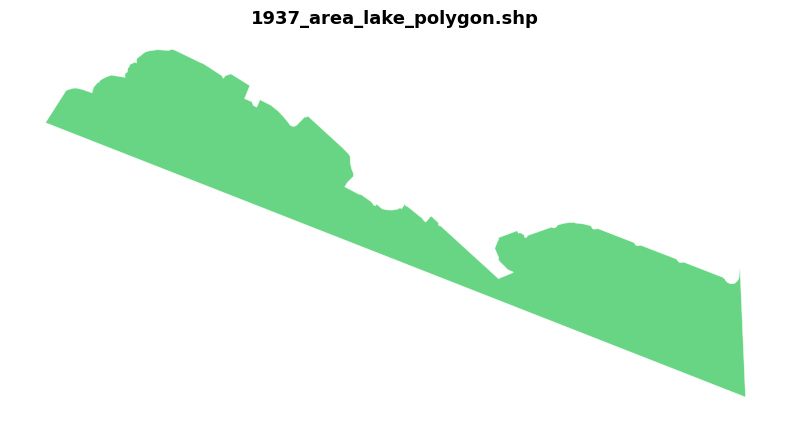


1937_lake.gpkg
Rows: 3
Geometry types:
MultiLineString    3
Name: count, dtype: int64


,id,geometry
0,0,"MULTILINESTRING ((2535880.574 1151550.365, 2535909.94 1151559.811, 2535923.866 1151560.772, 2535953.399 1151554.289, 2535994.458 1151539.402, 2535998.78 1151556.209, 2536001.301 1151563.773, 2536011.626 1151576.259, 2536020.27 1151586.223, 2536022.311 1151584.422, 2536026.993 1151587.304, 2536025.432 1151590.905, 2536039.598 1151600.75, 2536055.446 1151608.673, 2536069.132 1151614.196, 2536080.297 1151617.317, 2536140.204 1151607.713, 2536140.324 1151613.835, 2536140.324 1151619.958, 2536139.844 1151624.88, 2536149.568 1151630.763, 2536150.589 1151643.249, 2536153.23 1151649.432, 2536159.713 1151656.395, 2536160.613 1151664.198, 2536168.177 1151668.28, 2536182.523 1151674.463, 2536186.185 1151675.003, 2536190.867 1151671.041, 2536191.047 1151682.446, 2536191.587 1151689.53, 2536194.889 1151694.872, 2536200.591 1151698.114, 2536205.754 1151700.995, 2536215.898 1151709.219, 2536225.622 1151717.682, 2536237.088 1151722.004, 2536247.833 1151724.886, 2536264.64 1151728.307, 2536283.008 1151729.748, 2536308.94 1151729.028, 2536334.031 1151726.386, 2536337.633 1151729.508, 2536349.999 1151731.068, 2536361.524 1151726.747))"
1,0,"MULTILINESTRING ((2536361.526 1151726.744, 2536462.06 1151679.263, 2536476.085 1151671.361, 2536482.801 1151669.386, 2536515.198 1151649.04, 2536562.014 1151617.829, 2536567.545 1151614.47, 2536571.101 1151606.174, 2536574.459 1151603.803, 2536581.175 1151614.075, 2536587.299 1151616.841, 2536601.127 1151620.594, 2536607.053 1151623.162, 2536637.474 1151607.557, 2536690.019 1151571.407, 2536666.808 1151514.121, 2536699.105 1151500.195, 2536705.92 1151483.503, 2536720.637 1151476.49, 2536724.983 1151485.379, 2536734.563 1151509.183, 2536782.664 1151485.182, 2536814.27 1151459.897, 2536840.74 1151431.847, 2536862.074 1151405.772, 2536865.63 1151399.055, 2536874.914 1151392.932, 2536886.371 1151391.549, 2536896.248 1151396.883, 2536907.903 1151408.537, 2536931.706 1151433.328, 2536939.509 1151432.341, 2536946.028 1151437.477, 2536974.078 1151411.105, 2537018.722 1151369.622, 2537098.033 1151298.114, 2537125.491 1151270.261, 2537132.405 1151258.606, 2537132.207 1151248.137, 2537132.602 1151231.938, 2537138.923 1151203.493, 2537146.232 1151185.912, 2537147.417 1151174.455, 2537145.047 1151169.912, 2537132.602 1151157.072, 2537119.96 1151144.627, 2537108.503 1151125.466, 2537134.182 1151111.44, 2537159.072 1151099.193, 2537167.961 1151094.057, 2537182.184 1151090.106, 2537225.84 1151059.29, 2537236.705 1151043.882, 2537240.705 1151043.833, 2537242.779 1151041.413, 2537249.396 1151048.821, 2537272.953 1151028.326, 2537282.78 1151025.215, 2537292.657 1151023.734, 2537316.954 1151022.746, 2537334.239 1151025.314, 2537343.326 1151027.684, 2537352.215 1151033.117, 2537358.536 1151028.376, 2537366.042 1151039.191, 2537372.462 1151048.278, 2537374.339 1151046.796, 2537375.821 1151042.45, 2537386.29 1151037.907, 2537404.661 1151023.684, 2537418.785 1151012.721, 2537454.243 1150983.14, 2537452.465 1150981.362, 2537465.108 1150969.707, 2537486.738 1150994.152, 2537489.405 1150996.671, 2537522.344 1150966.003, 2537520.566 1150962.694, 2537521.406 1150957.805, 2537524.468 1150953.558, 2537531.727 1150952.571, 2537617.014 1150874.839, 2537686.004 1150812.319, 2537784.724 1150721.797, 2537786.847 1150720.908, 2537828.627 1150738.637, 2537851.344 1150747.724, 2537849.072 1150750.687, 2537826.849 1150760.169, 2537812.626 1150774.885, 2537794.551 1150792.762, 2537787.835 1150800.565, 2537784.675 1150807.775, 2537787.588 1150811.529, 2537776.23 1150839.233, 2537769.711 1150854.197, 2537784.181 1150889.951, 2537787.588 1150891.482, 2537784.576 1150900.569, 2537814.058 1150911.532, 2537868.579 1150931.878, 2537873.517 1150920.718, 2537881.246 1150923.162, 2537900.111 1150912.791, 2537899.716 1150909.236, 2537899.716 1150905.581, 2537901.79 1150902.816, 2537904.16 1150901.63, 2537907.025 1150901.63, 2537909.938 1150902.668, 2537913.049 1150908.248, 2537914.729 1150910.767, 2537923.42 1150913.68, 2538020.016 1150947.85

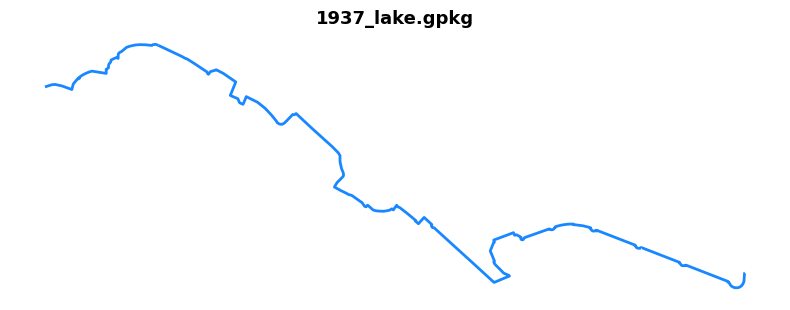


1959_area_lake.gpkg
Rows: 3
Geometry types:
MultiLineString    3
Name: count, dtype: int64


,id,name,Name_1,length,geometry
0,NaN,lake side,None,1383.603559,"MULTILINESTRING ((2538960.729 1150699.624, 2538848.431 1150716.85, 2538809.3 1150699.043, 2538778.816 1150717.914, 2538558.171 1150812.269, 2538221.398 1150944.365, 2538144.462 1150970.494, 2538071.882 1150966.14, 2538016.72 1150948.72))"
1,NaN,lake side,None,2171.345509,"MULTILINESTRING ((2538016.72 1150948.72, 2537909.301 1150909.527, 2537861.398 1150926.946, 2537787.366 1150899.366, 2537764.14 1150852.914, 2537793.172 1150796.301, 2537865.753 1150739.688, 2537783.011 1150723.721, 2537489.786 1150996.623, 2537463.657 1150974.849, 2537372.205 1151050.333, 2537337.367 1151024.204, 2537267.689 1151030.011, 2537109.464 1151125.817, 2537144.302 1151175.172, 2537125.431 1151276.784, 2536948.335 1151439.365, 2536888.819 1151395.816, 2536867.045 1151400.171, 2536859.787 1151423.397, 2536790.109 1151484.365, 2536739.303 1151511.945, 2536723.335 1151480.01, 2536668.174 1151527.913))"
2,NaN,lake side,None,1080.992212,"MULTILINESTRING ((2536668.174 1151527.913, 2536687.045 1151578.719, 2536611.561 1151629.526, 2536576.722 1151612.106, 2536476.561 1151678.881, 2536350.271 1151739.848, 2536241.4 1151732.59, 2536186.239 1151697.752, 2536136.884 1151616.461, 2536080.272 1151622.268, 2536032.368 1151607.752, 2536001.885 1151568.558, 2535997.53 1151548.236, 2535935.11 1151567.107, 2535883.361 1151558.936))"


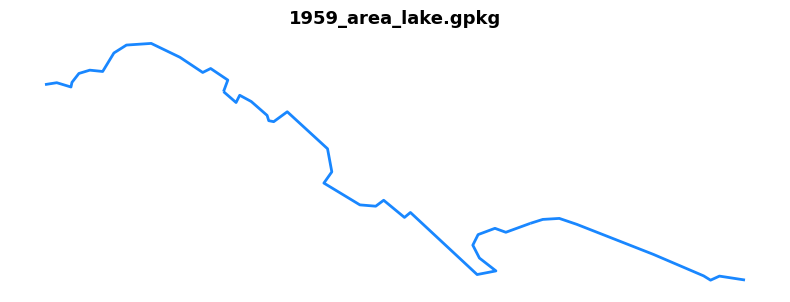


1959_area_lake_polygon.shp
Rows: 1
Geometry types:
Polygon    1
Name: count, dtype: int64


,geometry
0,"POLYGON ((2538852.36 1150716.247, 2538873.276 1150200.085, 2535789.602 1151406.924, 2535883.361 1151558.936, 2535935.11 1151567.107, 2535997.53 1151548.236, 2536001.885 1151568.558, 2536032.368 1151607.752, 2536080.272 1151622.268, 2536136.884 1151616.461, 2536186.239 1151697.752, 2536241.4 1151732.59, 2536350.271 1151739.848, 2536476.561 1151678.881, 2536576.722 1151612.106, 2536611.561 1151629.526, 2536687.045 1151578.719, 2536668.174 1151527.913, 2536723.335 1151480.01, 2536739.303 1151511.945, 2536790.109 1151484.365, 2536859.787 1151423.397, 2536867.045 1151400.171, 2536888.819 1151395.816, 2536948.335 1151439.365, 2537125.431 1151276.784, 2537144.302 1151175.172, 2537109.464 1151125.817, 2537267.689 1151030.011, 2537337.367 1151024.204, 2537372.205 1151050.333, 2537463.657 1150974.849, 2537489.786 1150996.623, 2537783.011 1150723.721, 2537865.753 1150739.688, 2537793.172 1150796.301, 2537764.14 1150852.914, 2537787.366 1150899.366, 2537861.398 1150926.946, 2537909.301 1150909.527, 2538016.72 1150948.72, 2538071.882 1150966.14, 2538144.462 1150970.494, 2538221.398 1150944.365, 2538558.171 1150812.269, 2538778.816 1150717.914, 2538809.3 1150699.043, 2538848.431 1150716.85, 2538852.36 1150716.247))"


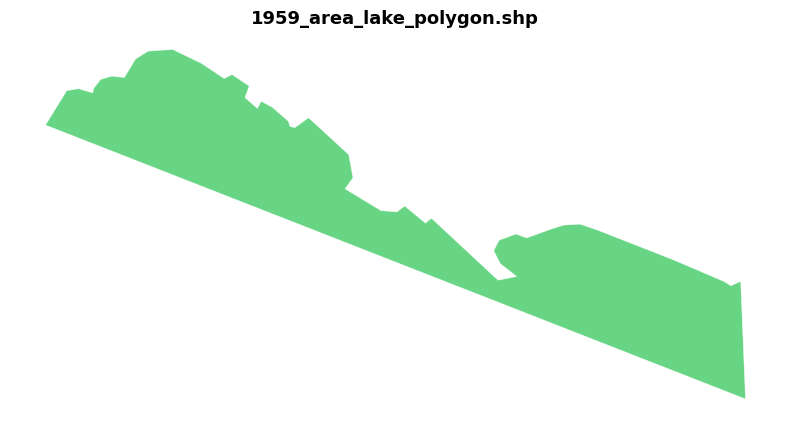


1959_lake.gpkg
Rows: 3
Geometry types:
MultiLineString    3
Name: count, dtype: int64


,id,name,Name_1,length,geometry
0,NaN,lake side,None,1383.603559,"MULTILINESTRING ((2538960.729 1150699.624, 2538848.431 1150716.85, 2538809.3 1150699.043, 2538778.816 1150717.914, 2538558.171 1150812.269, 2538221.398 1150944.365, 2538144.462 1150970.494, 2538071.882 1150966.14, 2538016.72 1150948.72))"
1,NaN,lake side,None,2171.345509,"MULTILINESTRING ((2538016.72 1150948.72, 2537909.301 1150909.527, 2537861.398 1150926.946, 2537787.366 1150899.366, 2537764.14 1150852.914, 2537793.172 1150796.301, 2537865.753 1150739.688, 2537783.011 1150723.721, 2537489.786 1150996.623, 2537463.657 1150974.849, 2537372.205 1151050.333, 2537337.367 1151024.204, 2537267.689 1151030.011, 2537109.464 1151125.817, 2537144.302 1151175.172, 2537125.431 1151276.784, 2536948.335 1151439.365, 2536888.819 1151395.816, 2536867.045 1151400.171, 2536859.787 1151423.397, 2536790.109 1151484.365, 2536739.303 1151511.945, 2536723.335 1151480.01, 2536668.174 1151527.913))"
2,NaN,lake side,None,1080.992212,"MULTILINESTRING ((2536668.174 1151527.913, 2536687.045 1151578.719, 2536611.561 1151629.526, 2536576.722 1151612.106, 2536476.561 1151678.881, 2536350.271 1151739.848, 2536241.4 1151732.59, 2536186.239 1151697.752, 2536136.884 1151616.461, 2536080.272 1151622.268, 2536032.368 1151607.752, 2536001.885 1151568.558, 2535997.53 1151548.236, 2535935.11 1151567.107, 2535883.361 1151558.936))"


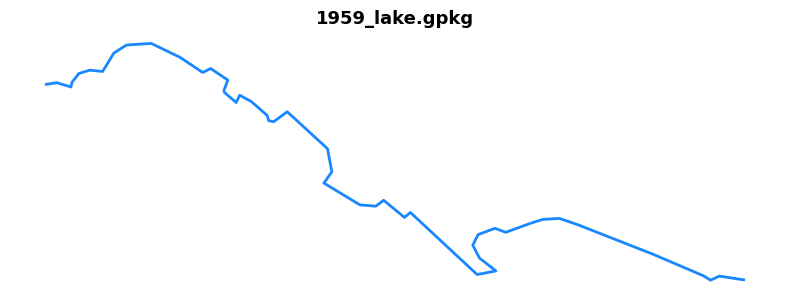


berney_area_lake.gpkg
Rows: 1
Geometry types:
MultiLineString    1
Name: count, dtype: int64


,id,geometry
0,1,"MULTILINESTRING ((2535901.445 1151605.094, 2535914.415 1151606.862, 2535946.28 1151595.999, 2535972.352 1151593.827, 2535989.733 1151598.896, 2536021.599 1151602.517, 2536063.603 1151601.793, 2536096.193 1151610.665, 2536107.056 1151617.907, 2536113.937 1151618.631, 2536142.543 1151628.77, 2536150.509 1151633.839, 2536172.598 1151645.065, 2536210.438 1151666.067, 2536226.009 1151676.93, 2536233.794 1151685.259, 2536237.687 1151691.777, 2536243.662 1151693.949, 2536244.205 1151693.949, 2536281.502 1151715.495, 2536313.911 1151731.971, 2536356.82 1151752.249, 2536374.926 1151754.421, 2536390.859 1151755.146, 2536414.396 1151748.628, 2536478.489 1151725.091, 2536512.165 1151705.537, 2536542.039 1151684.535, 2536569.378 1151663.17, 2536592.372 1151641.806, 2536602.873 1151637.461, 2536609.391 1151637.098, 2536620.435 1151645.246, 2536629.488 1151646.151, 2536639.808 1151641.444, 2536656.465 1151630.943, 2536697.745 1151592.559, 2536709.333 1151584.593, 2536723.093 1151583.869, 2536729.611 1151587.128, 2536740.836 1151587.128, 2536773.788 1151574.454, 2536839.692 1151540.416, 2536859.607 1151524.483, 2536873.73 1151517.965, 2536882.058 1151517.965, 2536886.041 1151520.862, 2536894.37 1151520.5, 2536905.233 1151515.43, 2536944.703 1151485.737, 2536972.947 1151454.596, 2536989.604 1151440.112, 2537011.331 1151414.04, 2537019.659 1151401.366, 2537031.971 1151391.227, 2537039.753 1151394.411), (2537039.753 1151394.411, 2537039.937 1151394.486, 2537039.575 1151394.486, 2537039.753 1151394.411), (2537039.753 1151394.411, 2537048.99 1151390.503, 2537068.725 1151374.208, 2537096.245 1151344.153, 2537107.832 1151330.393, 2537125.938 1151306.494, 2537136.077 1151297.441, 2537164.683 1151264.127, 2537176.995 1151258.333, 2537187.134 1151245.298, 2537222.621 1151219.226, 2537243.623 1151196.775, 2537298.663 1151154.771, 2537371.085 1151125.078, 2537437.713 1151099.006, 2537512.307 1151056.277, 2537544.173 1151031.654, 2537560.83 1151013.548, 2537576.038 1150992.908, 2537601.386 1150953.801, 2537606.455 1150947.283, 2537623.112 1150929.539, 2537653.529 1150904.192, 2537663.306 1150893.329, 2537665.117 1150880.836, 2537670.91 1150872.145, 2537676.885 1150870.516, 2537682.498 1150870.878, 2537689.378 1150873.413, 2537731.383 1150863.998, 2537751.661 1150874.137, 2537758.541 1150891.156, 2537778.819 1150915.055, 2537799.097 1150932.436, 2537823.72 1150944.024, 2537841.101 1150943.299, 2537851.24 1150940.403, 2537862.104 1150930.264, 2537929.093 1150958.146, 2537934.887 1150956.697, 2537999.705 1150981.683, 2538006.947 1150983.856, 2538028.311 1150993.632, 2538048.951 1150999.426, 2538060.539 1151001.237, 2538098.56 1151010.652, 2538151.066 1151012.1, 2538188.363 1151007.03, 2538230.005 1150998.34, 2538248.835 1150993.995, 2538274.182 1150982.407, 2538274.907 1150982.407, 2538289.391 1150978.062, 2538303.875 1150967.923, 2538324.153 1150959.956, 2538350.949 1150948.369, 2538383.539 1150933.16, 2538399.472 1150927.367, 2538410.335 1150924.47, 2538429.889 1150917.952, 2538460.306 1150907.089, 2538506.656 1150886.811, 2538529.831 1150878.12, 2538571.835 1150862.187, 2538613.116 1150844.806, 2538641.36 1150827.425, 2538710.885 1150779.627, 2538743.474 1150767.315, 2538773.892 1150765.142, 2538797.791 1150769.488, 2538827.483 1150778.178, 2538839.071 1150764.418, 2538843.416 1150758.624, 2538861.522 1150755.728, 2538904.975 1150755.003, 2538945.531 1150748.485, 2538976.454 1150737.958))"


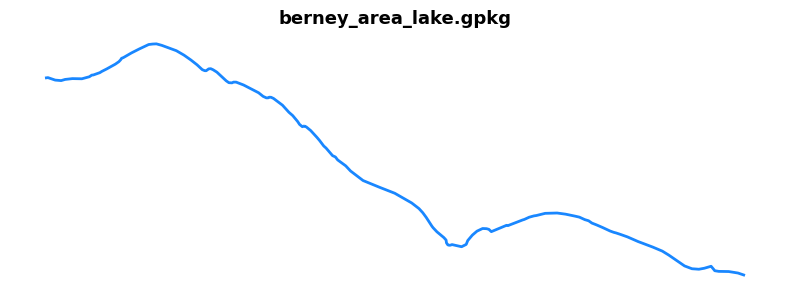


berney_area_lake_polygon.shp
Rows: 1
Geometry types:
Polygon    1
Name: count, dtype: int64


,geometry
0,"POLYGON ((2538976.454 1150737.958, 2538875.714 1150198.882, 2535789.829 1151407.813, 2535901.445 1151605.094, 2535914.415 1151606.862, 2535946.28 1151595.999, 2535972.352 1151593.827, 2535989.733 1151598.896, 2536021.599 1151602.517, 2536063.603 1151601.793, 2536096.193 1151610.665, 2536107.056 1151617.907, 2536113.937 1151618.631, 2536142.543 1151628.77, 2536150.509 1151633.839, 2536172.598 1151645.065, 2536226.009 1151676.93, 2536233.794 1151685.259, 2536237.687 1151691.777, 2536244.205 1151693.949, 2536313.911 1151731.971, 2536356.82 1151752.249, 2536390.859 1151755.146, 2536478.489 1151725.091, 2536512.165 1151705.537, 2536542.039 1151684.535, 2536592.372 1151641.806, 2536609.391 1151637.098, 2536620.435 1151645.246, 2536629.488 1151646.151, 2536639.808 1151641.444, 2536656.465 1151630.943, 2536709.333 1151584.593, 2536723.093 1151583.869, 2536729.611 1151587.128, 2536740.836 1151587.128, 2536773.788 1151574.454, 2536839.692 1151540.416, 2536859.607 1151524.483, 2536873.73 1151517.965, 2536882.058 1151517.965, 2536886.041 1151520.862, 2536894.37 1151520.5, 2536905.233 1151515.43, 2536944.703 1151485.737, 2536989.604 1151440.112, 2537011.331 1151414.04, 2537019.659 1151401.366, 2537031.971 1151391.227, 2537039.937 1151394.486, 2537048.99 1151390.503, 2537068.725 1151374.208, 2537125.938 1151306.494, 2537136.077 1151297.441, 2537164.683 1151264.127, 2537176.995 1151258.333, 2537187.134 1151245.298, 2537222.621 1151219.226, 2537243.623 1151196.775, 2537298.663 1151154.771, 2537437.713 1151099.006, 2537512.307 1151056.277, 2537544.173 1151031.654, 2537576.038 1150992.908, 2537606.455 1150947.283, 2537623.112 1150929.539, 2537653.529 1150904.192, 2537663.306 1150893.329, 2537665.117 1150880.836, 2537670.91 1150872.145, 2537682.498 1150870.878, 2537689.378 1150873.413, 2537731.383 1150863.998, 2537751.661 1150874.137, 2537758.541 1150891.156, 2537778.819 1150915.055, 2537799.097 1150932.436, 2537823.72 1150944.024, 2537841.101 1150943.299, 2537851.24 1150940.403, 2537862.104 1150930.264, 2537929.093 1150958.146, 2537934.887 1150956.697, 2538028.311 1150993.632, 2538098.56 1151010.652, 2538151.066 1151012.1, 2538188.363 1151007.03, 2538248.835 1150993.995, 2538274.182 1150982.407, 2538289.391 1150978.062, 2538303.875 1150967.923, 2538383.539 1150933.16, 2538460.306 1150907.089, 2538506.656 1150886.811, 2538613.116 1150844.806, 2538641.36 1150827.425, 2538710.885 1150779.627, 2538743.474 1150767.315, 2538773.892 1150765.142, 2538827.483 1150778.178, 2538843.416 1150758.624, 2538861.522 1150755.728, 2538904.975 1150755.003, 2538945.531 1150748.485, 2538976.454 1150737.958))"


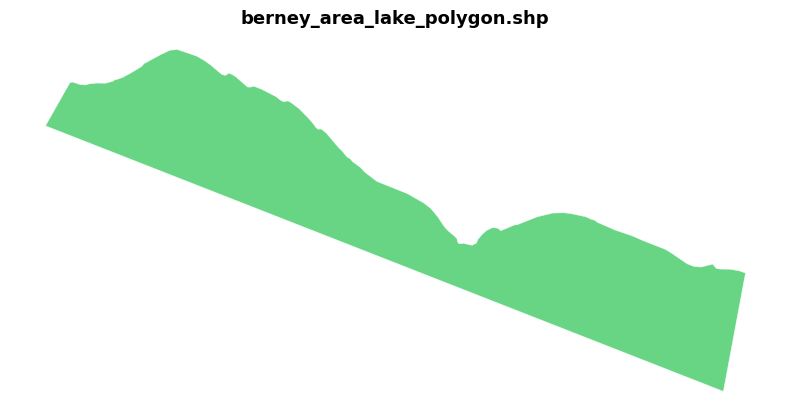


berney_lake.gpkg
Rows: 1
Geometry types:
MultiLineString    1
Name: count, dtype: int64


,id,geometry
0,1,"MULTILINESTRING ((2535901.445 1151605.094, 2535914.415 1151606.862, 2535946.28 1151595.999, 2535972.352 1151593.827, 2535989.733 1151598.896, 2536021.599 1151602.517, 2536063.603 1151601.793, 2536096.193 1151610.665, 2536107.056 1151617.907, 2536113.937 1151618.631, 2536142.543 1151628.77, 2536150.509 1151633.839, 2536172.598 1151645.065, 2536210.438 1151666.067, 2536226.009 1151676.93, 2536233.794 1151685.259, 2536237.687 1151691.777, 2536243.662 1151693.949, 2536244.205 1151693.949, 2536281.502 1151715.495, 2536313.911 1151731.971, 2536356.82 1151752.249, 2536374.926 1151754.421, 2536390.859 1151755.146, 2536414.396 1151748.628, 2536478.489 1151725.091, 2536512.165 1151705.537, 2536542.039 1151684.535, 2536569.378 1151663.17, 2536592.372 1151641.806, 2536602.873 1151637.461, 2536609.391 1151637.098, 2536620.435 1151645.246, 2536629.488 1151646.151, 2536639.808 1151641.444, 2536656.465 1151630.943, 2536697.745 1151592.559, 2536709.333 1151584.593, 2536723.093 1151583.869, 2536729.611 1151587.128, 2536740.836 1151587.128, 2536773.788 1151574.454, 2536839.692 1151540.416, 2536859.607 1151524.483, 2536873.73 1151517.965, 2536882.058 1151517.965, 2536886.041 1151520.862, 2536894.37 1151520.5, 2536905.233 1151515.43, 2536944.703 1151485.737, 2536972.947 1151454.596, 2536989.604 1151440.112, 2537011.331 1151414.04, 2537019.659 1151401.366, 2537031.971 1151391.227, 2537039.753 1151394.411), (2537039.753 1151394.411, 2537039.937 1151394.486, 2537039.575 1151394.486, 2537039.753 1151394.411), (2537039.753 1151394.411, 2537048.99 1151390.503, 2537068.725 1151374.208, 2537096.245 1151344.153, 2537107.832 1151330.393, 2537125.938 1151306.494, 2537136.077 1151297.441, 2537164.683 1151264.127, 2537176.995 1151258.333, 2537187.134 1151245.298, 2537222.621 1151219.226, 2537243.623 1151196.775, 2537298.663 1151154.771, 2537371.085 1151125.078, 2537437.713 1151099.006, 2537512.307 1151056.277, 2537544.173 1151031.654, 2537560.83 1151013.548, 2537576.038 1150992.908, 2537601.386 1150953.801, 2537606.455 1150947.283, 2537623.112 1150929.539, 2537653.529 1150904.192, 2537663.306 1150893.329, 2537665.117 1150880.836, 2537670.91 1150872.145, 2537676.885 1150870.516, 2537682.498 1150870.878, 2537689.378 1150873.413, 2537731.383 1150863.998, 2537751.661 1150874.137, 2537758.541 1150891.156, 2537778.819 1150915.055, 2537799.097 1150932.436, 2537823.72 1150944.024, 2537841.101 1150943.299, 2537851.24 1150940.403, 2537862.104 1150930.264, 2537929.093 1150958.146, 2537934.887 1150956.697, 2537999.705 1150981.683, 2538006.947 1150983.856, 2538028.311 1150993.632, 2538048.951 1150999.426, 2538060.539 1151001.237, 2538098.56 1151010.652, 2538151.066 1151012.1, 2538188.363 1151007.03, 2538230.005 1150998.34, 2538248.835 1150993.995, 2538274.182 1150982.407, 2538274.907 1150982.407, 2538289.391 1150978.062, 2538303.875 1150967.923, 2538324.153 1150959.956, 2538350.949 1150948.369, 2538383.539 1150933.16, 2538399.472 1150927.367, 2538410.335 1150924.47, 2538429.889 1150917.952, 2538460.306 1150907.089, 2538506.656 1150886.811, 2538529.831 1150878.12, 2538571.835 1150862.187, 2538613.116 1150844.806, 2538641.36 1150827.425, 2538710.885 1150779.627, 2538743.474 1150767.315, 2538773.892 1150765.142, 2538797.791 1150769.488, 2538827.483 1150778.178, 2538839.071 1150764.418, 2538843.416 1150758.624, 2538861.522 1150755.728, 2538904.975 1150755.003, 2538945.531 1150748.485, 2538976.454 1150737.958))"


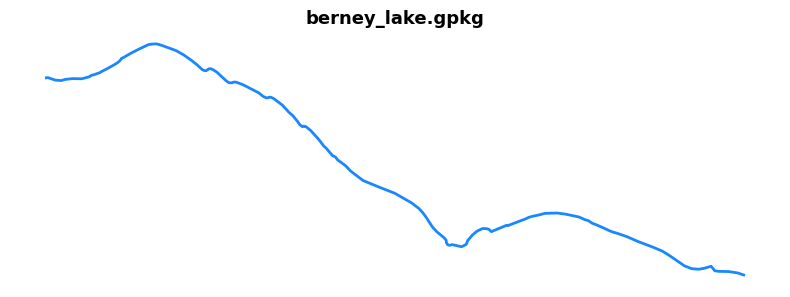


contemporain_area_lake.gpkg
Rows: 1
Geometry types:
MultiLineString    1
Name: count, dtype: int64


id  length  \
0 NaN     NaN   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

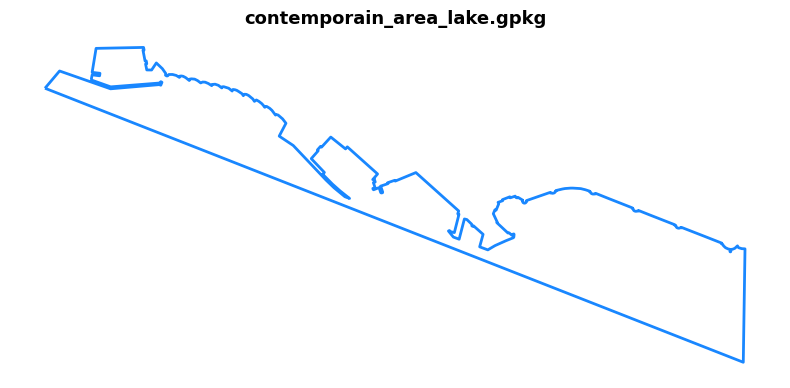


contemporain_area_lake_polygon.shp
Rows: 1
Geometry types:
Polygon    1
Name: count, dtype: int64


geometry
0  POLYGON ((2538882.687 1150699.266, 2538875.09 1150198.265, 2535790.068 1151408.907, 2535854.432 1151485.095, 2536079.618 1151406.381, 2536295.397 1151424.898, 2536301.538 1151422.064, 2536306.923 1151435.196, 2536302.01 1151437.841, 2536294.641 1151431.795, 2536080.374 1151414.978, 2535996.67 1151444.643, 2535994.969 1151450.689, 2535998.37 1151468.073, 2536031.342 1151463.916, 2536032.948 1151474.875, 2535998.37 1151479.032, 2536015.754 1151585.032, 2536225.486 1151589.188, 2536227.753 1151577.852, 2536222.841 1151577.285, 2536232.194 1151528.819, 2536237.579 1151529.481, 2536239.657 1151517.199, 2536234.367 1151516.16, 2536239.752 1151489.707, 2536261.103 1151489.518, 2536281.887 1151520.6, 2536308.529 1151495.376, 2536323.739 1151473.741, 2536322.369 1151466.514, 2536327.943 1151462.877, 2536332.62 1151463.963, 2536337.343 1151469.631, 2536353.593 1151469.679, 2536369.89 1151465.38, 2536383.824 1151456.877, 2536386.47 1151462.64, 2536393.225 1151462.971, 2536400.31 1151461.648, 2536411.553 1151455.791, 2536427.613 1151443.037, 2536429.786 1151449.272, 2536436.683 1151450.406, 2536451.326 1151449.083, 2536463.891 1151442.848, 2536477.779 1151432.456, 2536486.66 1151436.329, 2536497.855 1151435.621, 2536511.884 1151429.669, 2536526.622 1151420.41, 2536528.7 1151425.607, 2536541.549 1151426.74, 2536556.192 1151421.733, 2536571.025 1151410.302, 2536572.725 1151415.12, 2536579.811 1151415.592, 2536601.54 1151408.885, 2536616.939 1151396.603, 2536620.34 1151403.405, 2536629.504 1151402.177, 2536637.535 1151399.437, 2536645.659 1151394.525, 2536660.397 1151384.699, 2536666.444 1151375.819, 2536669.089 1151381.487, 2536672.49 1151382.432, 2536679.859 1151381.676, 2536689.495 1151376.952, 2536708.579 1151361.27, 2536715.287 1151350.783, 2536723.884 1151357.113, 2536734.654 1151351.161, 2536737.866 1151348.705, 2536747.786 1151340.863, 2536754.21 1151333.872, 2536760.445 1151325.086, 2536762.051 1151325.086, 2536765.264 1151328.582, 2536769.704 1151328.298, 2536782.883 1151320.173, 2536792.708 1151311.198, 2536808.391 1151290.32, 2536810.375 1151293.059, 2536819.917 1151290.509, 2536839.709 1151273.551, 2536854.636 1151254.183, 2536824.782 1151197.31, 2536886.852 1151155.93, 2536961.392 1151077.328, 2537031.586 1151003.26, 2537067.108 1150969.061, 2537115.003 1150929.668, 2537135.672 1150921.98, 2537093.75 1150955.362, 2537059.739 1150985.594, 2537018.171 1151027.729, 2537017.037 1151029.335, 2537024.5 1151036.893, 2536966.399 1151097.829, 2536997.008 1151132.595, 2536993.418 1151136.28, 2537007.401 1151152.151, 2537011.746 1151148.467, 2537052.654 1151193.153, 2537117.935 1151140.72, 2537125.493 1151150.073, 2537259.457 1151030.091, 2537237.917 1151005.339, 2537245.003 1151007.228, 2537249.065 1150994.663, 2537240.752 1150992.112, 2537248.404 1150969.533, 2537238.39 1150966.274, 2537239.523 1150962.542, 2537241.744 1150960.322, 2537266.165 1150969.958, 2537273.251 1150947.662, 2537276.321 1150946.103, 2537281.234 1150947.237, 2537282.084 1150950.119, 2537275.66 1150968.824, 2537273.298 1150972.414, 2537272.211 1150976.146, 2537305.325 1150987.341, 2537303.813 1150991.498, 2537335.722 1151002.245, 2537337.28 1150998.56, 2537428.637 1151036.303, 2537617.774 1150866.674, 2537613.428 1150854.015, 2537619.097 1150852.125, 2537598.596 1150771.067, 2537580.551 1150775.601, 2537576.961 1150780.231, 2537572.426 1150778.152, 2537594.226 1150751.417, 2537619.775 1150741.913, 2537642.999 1150831.436, 2537653.863 1150828.743, 2537675.403 1150808.006, 2537675.923 1150800.873, 2537679.607 1150798.7, 2537683.197 1150801.109, 2537725.569 1150763.461, 2537710.411 1150708.2, 2537746.543 1150694.761, 2537764.776 1150705.643, 2537778.474 1150713.674, 2537827.034 1150735.403, 2537859.533 1150748.44, 2537861.517 1150751.652, 2537862.556 1150763.556, 2537861.328 1150765.162, 2537857.644 1150764.312, 2537852.92 1150759.21, 2537840.827 1150769.791, 2537838.371 1150770.264, 2537835.253 1150769.319, 2537786.316 1150814.95, 2537788.583 1150816.367, 

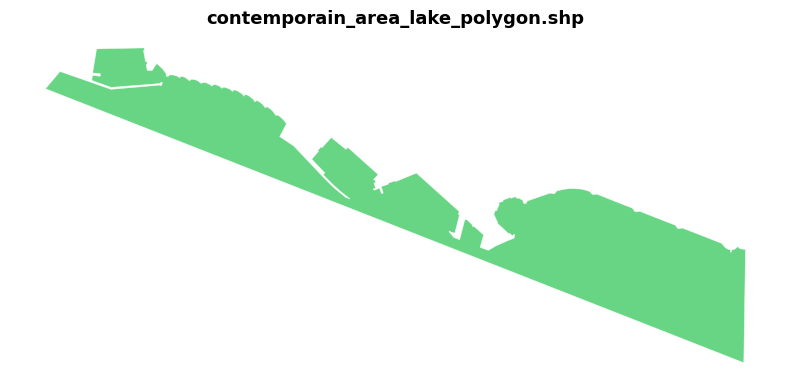


contemporain_lake.gpkg
Rows: 1
Geometry types:
MultiLineString    1
Name: count, dtype: int64


id       length  \
0 NaN  9271.709734   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

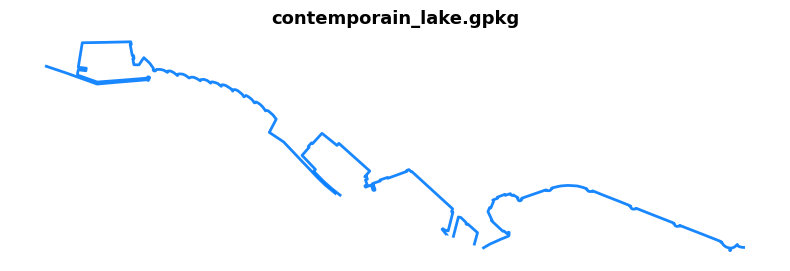


melotte_area_lake.gpkg
Rows: 2
Geometry types:
MultiLineString    2
Name: count, dtype: int64


,id,geometry
0,11,"MULTILINESTRING ((2535909.962 1151626.835, 2535958.683 1151630.603, 2535990.717 1151633.693, 2536035.597 1151639.222, 2536068.932 1151644.913, 2536092.266 1151655.401, 2536116.983 1151666.296, 2536144.383 1151680.687, 2536181.783 1151704.753, 2536227.151 1151734.348, 2536256.421 1151754.512, 2536270.893 1151763.943, 2536278.373 1151766.707, 2536308.293 1151763.455, 2536340.977 1151757.601, 2536381.142 1151743.454, 2536433.827 1151723.616, 2536479.683 1151704.428, 2536518.059 1151688.33, 2536542.288 1151676.622, 2536570.744 1151665.076, 2536595.136 1151652.393, 2536675.79 1151601.821, 2536708.149 1151585.723, 2536738.069 1151571.088, 2536753.843 1151563.446, 2536780.185 1151554.99, 2536801.162 1151548.811, 2536817.911 1151540.192, 2536847.993 1151522.631, 2536878.076 1151507.833, 2536908.321 1151494.987, 2536954.99 1151460.514, 2536993.366 1151437.749, 2537017.107 1151416.609, 2537042.637 1151393.194, 2537071.419 1151369.453, 2537092.72 1151349.452, 2537135.812 1151308.474, 2537188.497 1151263.757))"
1,12,"MULTILINESTRING ((2537188.497 1151263.757, 2537266.387 1151187.757, 2537491.764 1151048.726, 2537622.014 1150948.477, 2537674.882 1150900.548, 2537691.346 1150886.279, 2537691.346 1150881.523, 2537735.068 1150861.4, 2537756.654 1150850.973, 2537761.319 1150857.467, 2537744.078 1150864.693, 2537731.181 1150870.913, 2537719.336 1150876.675, 2537716.134 1150878.184, 2537713.207 1150878.596, 2537707.902 1150881.797, 2537705.844 1150884.038, 2537705.981 1150886.92, 2537707.628 1150890.029, 2537710.166 1150892.316, 2537714.328 1150890.853, 2537718.146 1150888.383, 2537719.656 1150886.782, 2537719.816 1150885.365, 2537724.526 1150885.502, 2537728.162 1150885.25, 2537729.923 1150884.724, 2537737.469 1150882.049, 2537744.329 1150879.351, 2537752.79 1150876.195, 2537759.147 1150874, 2537761.571 1150876.972, 2537764.772 1150878.71, 2537768.842 1150878.665, 2537770.306 1150876.972, 2537770.992 1150874.32, 2537770.9 1150870.89, 2537769.528 1150867.323, 2537774.285 1150872.856, 2537782.563 1150882.964, 2537795.46 1150886.714, 2537813.707 1150893.116, 2537827.702 1150898.787, 2537849.288 1150907.02, 2537861.545 1150909.764, 2537873.619 1150922.386, 2537936.823 1150955.955, 2537941.213 1150964.736, 2537940.116 1150971.321, 2537960.605 1150983.029, 2538007.436 1150984.493, 2538059.756 1150989.615, 2538090.184 1150991.414, 2538113.234 1150990.682, 2538197.018 1150966.779, 2538253.118 1150940.436, 2538290.193 1150924.337, 2538335.561 1150902.385, 2538380.929 1150882.872, 2538435.078 1150869.945, 2538469.226 1150860.432, 2538508.496 1150848.846, 2538550.572 1150833.479, 2538625.453 1150806.039, 2538658.26 1150791.892, 2538714.238 1150768.111, 2538747.898 1150755.671, 2538773.997 1150752.256, 2538784.607 1150752.866, 2538796.193 1150751.646, 2538807.657 1150744.085, 2538828.634 1150736.524))"


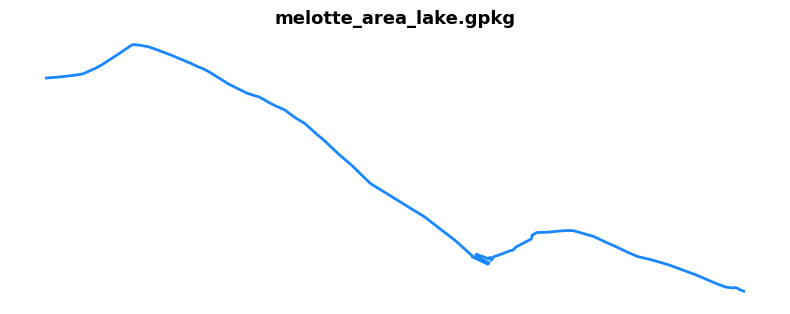


melotte_area_lake_polygon.shp
Rows: 1
Geometry types:
Polygon    1
Name: count, dtype: int64


,geometry
0,"POLYGON ((2538828.634 1150736.524, 2538874.456 1150198.528, 2535789.235 1151407.316, 2535909.962 1151626.835, 2535990.717 1151633.693, 2536068.932 1151644.913, 2536092.266 1151655.401, 2536116.983 1151666.296, 2536181.783 1151704.753, 2536278.373 1151766.707, 2536340.977 1151757.601, 2536381.142 1151743.454, 2536518.059 1151688.33, 2536570.744 1151665.076, 2536595.136 1151652.393, 2536675.79 1151601.821, 2536738.069 1151571.088, 2536753.843 1151563.446, 2536780.185 1151554.99, 2536801.162 1151548.811, 2536847.993 1151522.631, 2536878.076 1151507.833, 2536908.321 1151494.987, 2536954.99 1151460.514, 2537017.107 1151416.609, 2537266.387 1151187.757, 2537491.764 1151048.726, 2537622.014 1150948.477, 2537691.346 1150886.279, 2537691.346 1150881.523, 2537756.654 1150850.973, 2537761.319 1150857.467, 2537716.134 1150878.184, 2537707.902 1150881.797, 2537705.981 1150886.92, 2537710.166 1150892.316, 2537718.146 1150888.383, 2537719.816 1150885.365, 2537728.162 1150885.25, 2537759.147 1150874, 2537761.571 1150876.972, 2537764.772 1150878.71, 2537768.842 1150878.665, 2537770.992 1150874.32, 2537769.528 1150867.323, 2537782.563 1150882.964, 2537849.288 1150907.02, 2537861.545 1150909.764, 2537873.619 1150922.386, 2537936.823 1150955.955, 2537940.116 1150971.321, 2537960.605 1150983.029, 2538007.436 1150984.493, 2538059.756 1150989.615, 2538113.234 1150990.682, 2538197.018 1150966.779, 2538253.118 1150940.436, 2538380.929 1150882.872, 2538435.078 1150869.945, 2538469.226 1150860.432, 2538625.453 1150806.039, 2538658.26 1150791.892, 2538747.898 1150755.671, 2538773.997 1150752.256, 2538784.607 1150752.866, 2538796.193 1150751.646, 2538807.657 1150744.085, 2538828.634 1150736.524))"


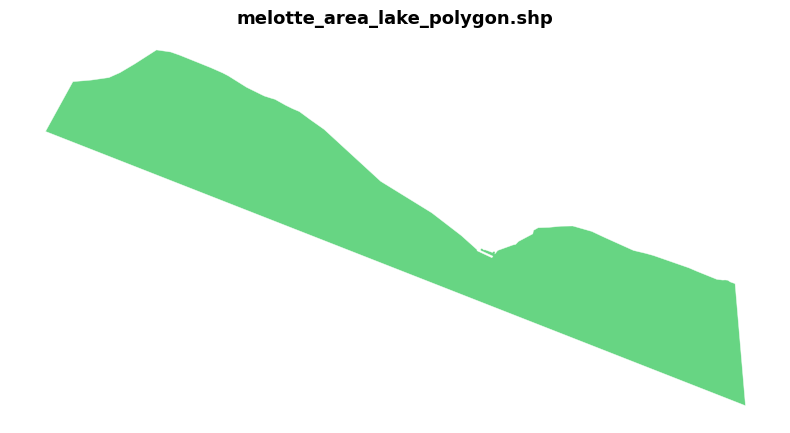


melotte_lake.gpkg
Rows: 2
Geometry types:
MultiLineString    2
Name: count, dtype: int64


,id,geometry
0,11,"MULTILINESTRING ((2535909.962 1151626.835, 2535958.683 1151630.603, 2535990.717 1151633.693, 2536035.597 1151639.222, 2536068.932 1151644.913, 2536092.266 1151655.401, 2536116.983 1151666.296, 2536144.383 1151680.687, 2536181.783 1151704.753, 2536227.151 1151734.348, 2536256.421 1151754.512, 2536270.893 1151763.943, 2536278.373 1151766.707, 2536308.293 1151763.455, 2536340.977 1151757.601, 2536381.142 1151743.454, 2536433.827 1151723.616, 2536479.683 1151704.428, 2536518.059 1151688.33, 2536542.288 1151676.622, 2536570.744 1151665.076, 2536595.136 1151652.393, 2536675.79 1151601.821, 2536708.149 1151585.723, 2536738.069 1151571.088, 2536753.843 1151563.446, 2536780.185 1151554.99, 2536801.162 1151548.811, 2536817.911 1151540.192, 2536847.993 1151522.631, 2536878.076 1151507.833, 2536908.321 1151494.987, 2536954.99 1151460.514, 2536993.366 1151437.749, 2537017.107 1151416.609, 2537042.637 1151393.194, 2537071.419 1151369.453, 2537092.72 1151349.452, 2537135.812 1151308.474, 2537188.497 1151263.757))"
1,12,"MULTILINESTRING ((2537188.497 1151263.757, 2537266.387 1151187.757, 2537491.764 1151048.726, 2537622.014 1150948.477, 2537674.882 1150900.548, 2537691.346 1150886.279, 2537691.346 1150881.523, 2537735.068 1150861.4, 2537756.654 1150850.973, 2537761.319 1150857.467, 2537744.078 1150864.693, 2537731.181 1150870.913, 2537719.336 1150876.675, 2537716.134 1150878.184, 2537713.207 1150878.596, 2537707.902 1150881.797, 2537705.844 1150884.038, 2537705.981 1150886.92, 2537707.628 1150890.029, 2537710.166 1150892.316, 2537714.328 1150890.853, 2537718.146 1150888.383, 2537719.656 1150886.782, 2537719.816 1150885.365, 2537724.526 1150885.502, 2537728.162 1150885.25, 2537729.923 1150884.724, 2537737.469 1150882.049, 2537744.329 1150879.351, 2537752.79 1150876.195, 2537759.147 1150874, 2537761.571 1150876.972, 2537764.772 1150878.71, 2537768.842 1150878.665, 2537770.306 1150876.972, 2537770.992 1150874.32, 2537770.9 1150870.89, 2537769.528 1150867.323, 2537774.285 1150872.856, 2537782.563 1150882.964, 2537795.46 1150886.714, 2537813.707 1150893.116, 2537827.702 1150898.787, 2537849.288 1150907.02, 2537861.545 1150909.764, 2537873.619 1150922.386, 2537936.823 1150955.955, 2537941.213 1150964.736, 2537940.116 1150971.321, 2537960.605 1150983.029, 2538007.436 1150984.493, 2538059.756 1150989.615, 2538090.184 1150991.414, 2538113.234 1150990.682, 2538197.018 1150966.779, 2538253.118 1150940.436, 2538290.193 1150924.337, 2538335.561 1150902.385, 2538380.929 1150882.872, 2538435.078 1150869.945, 2538469.226 1150860.432, 2538508.496 1150848.846, 2538550.572 1150833.479, 2538625.453 1150806.039, 2538658.26 1150791.892, 2538714.238 1150768.111, 2538747.898 1150755.671, 2538773.997 1150752.256, 2538784.607 1150752.866, 2538796.193 1150751.646, 2538807.657 1150744.085, 2538828.634 1150736.524))"


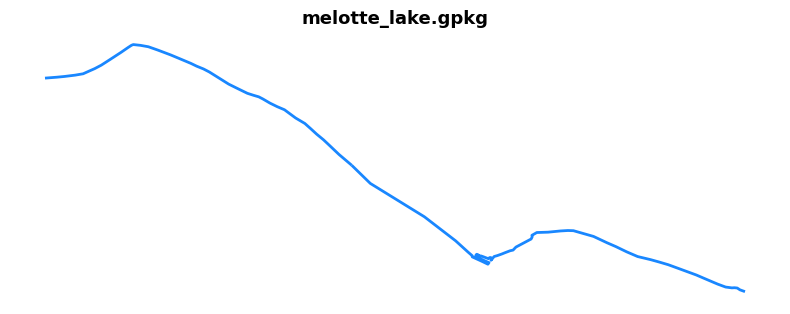


renove_area_lake.gpkg
Rows: 1
Geometry types:
MultiLineString    1
Name: count, dtype: int64


,id,geometry
0,NaN,"MULTILINESTRING ((2535892.255 1151581.638, 2535965.792 1151565.495, 2536021.957 1151572.742, 2536129.305 1151603.543, 2536185.017 1151642.496, 2536224.877 1151673.296, 2536248.43 1151692.32, 2536287.383 1151712.249, 2536329.054 1151720.402, 2536340.83 1151727.649, 2536348.077 1151741.238, 2536359.854 1151744.861, 2536408.772 1151735.802, 2536459.502 1151721.308, 2536504.796 1151694.132, 2536577.267 1151644.308, 2536606.256 1151633.437, 2536633.433 1151634.343, 2536682.351 1151594.484, 2536703.186 1151585.425, 2536724.021 1151593.578, 2536768.41 1151580.895, 2536906.105 1151514.766, 2537032.93 1151401.529, 2537055.577 1151394.282, 2537076.412 1151381.6, 2537176.966 1151276.517, 2537185.119 1151281.952, 2537187.837 1151278.328, 2537189.649 1151274.705, 2537184.213 1151277.423, 2537178.778 1151269.27, 2537182.401 1151267.458, 2537184.213 1151267.458, 2537290.202 1151177.775, 2537332.779 1151152.41, 2537446.921 1151106.209, 2537432.427 1151055.48, 2537790.253 1150734.795, 2537794.783 1150769.219, 2537852.759 1150746.571, 2537855.477 1150754.724, 2537851.854 1150763.783, 2537849.136 1150759.254, 2537799.312 1150781.901, 2537767.606 1150850.749, 2537784.818 1150897.855, 2537791.159 1150897.855, 2537785.724 1150907.82, 2537865.442 1150935.902, 2537868.16 1150928.655, 2538002.231 1150972.138, 2538023.067 1150908.726, 2538021.255 1150903.29, 2538028.502 1150903.29, 2538032.126 1150907.82, 2538027.596 1150910.537, 2538004.949 1150973.044, 2538081.044 1150999.315, 2538159.856 1150992.067, 2538176.162 1150995.691, 2538267.657 1150965.797, 2538275.81 1150967.608, 2538362.775 1150917.785, 2538401.728 1150912.349, 2538429.811 1150893.326, 2538476.011 1150888.796, 2538720.601 1150767.407, 2538749.59 1150772.842, 2538773.143 1150760.16, 2538825.684 1150713.054, 2538883.661 1150665.947, 2538929.024 1150622.329, 2538875.761 1150198.455, 2535789.735 1151408.667, 2535892.255 1151581.638))"


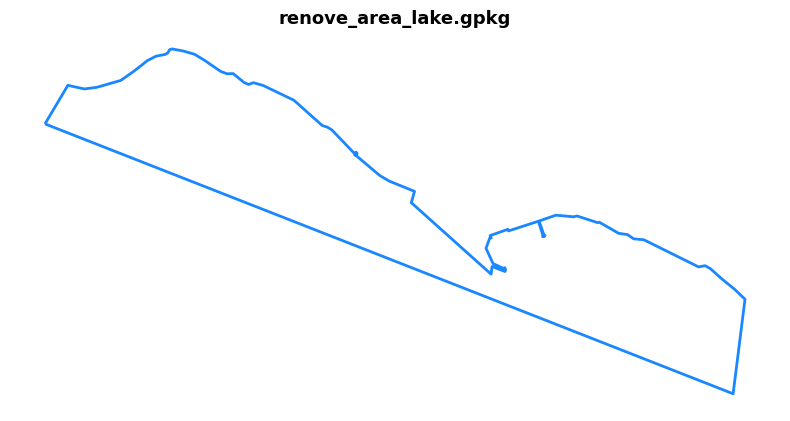


renove_area_lake_polygon.shp
Rows: 1
Geometry types:
Polygon    1
Name: count, dtype: int64


,geometry
0,"POLYGON ((2535892.255 1151581.638, 2535965.792 1151565.495, 2536021.957 1151572.742, 2536129.305 1151603.543, 2536185.017 1151642.496, 2536224.877 1151673.296, 2536248.43 1151692.32, 2536287.383 1151712.249, 2536329.054 1151720.402, 2536340.83 1151727.649, 2536348.077 1151741.238, 2536359.854 1151744.861, 2536408.772 1151735.802, 2536459.502 1151721.308, 2536504.796 1151694.132, 2536577.267 1151644.308, 2536606.256 1151633.437, 2536633.433 1151634.343, 2536682.351 1151594.484, 2536703.186 1151585.425, 2536724.021 1151593.578, 2536768.41 1151580.895, 2536906.105 1151514.766, 2537032.93 1151401.529, 2537055.577 1151394.282, 2537076.412 1151381.6, 2537176.966 1151276.517, 2537185.119 1151281.952, 2537187.837 1151278.328, 2537189.649 1151274.705, 2537184.213 1151277.423, 2537178.778 1151269.27, 2537182.401 1151267.458, 2537184.213 1151267.458, 2537290.202 1151177.775, 2537332.779 1151152.41, 2537446.921 1151106.209, 2537432.427 1151055.48, 2537790.253 1150734.795, 2537794.783 1150769.219, 2537852.759 1150746.571, 2537855.477 1150754.724, 2537851.854 1150763.783, 2537849.136 1150759.254, 2537799.312 1150781.901, 2537767.606 1150850.749, 2537784.818 1150897.855, 2537791.159 1150897.855, 2537785.724 1150907.82, 2537865.442 1150935.902, 2537868.16 1150928.655, 2538002.231 1150972.138, 2538023.067 1150908.726, 2538021.255 1150903.29, 2538028.502 1150903.29, 2538032.126 1150907.82, 2538027.596 1150910.537, 2538004.949 1150973.044, 2538081.044 1150999.315, 2538159.856 1150992.067, 2538176.162 1150995.691, 2538267.657 1150965.797, 2538275.81 1150967.608, 2538362.775 1150917.785, 2538401.728 1150912.349, 2538429.811 1150893.326, 2538476.011 1150888.796, 2538720.601 1150767.407, 2538749.59 1150772.842, 2538773.143 1150760.16, 2538825.684 1150713.054, 2538883.661 1150665.947, 2538929.024 1150622.329, 2538875.761 1150198.455, 2535789.735 1151408.667, 2535892.255 1151581.638))"


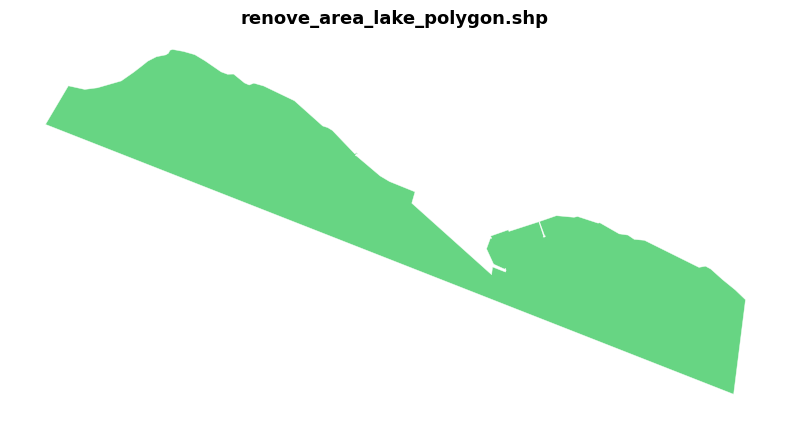


renove_lake.gpkg
Rows: 1
Geometry types:
MultiLineString    1
Name: count, dtype: int64


,id,geometry
0,1,"MULTILINESTRING ((2538929.024 1150622.329, 2538883.661 1150665.947, 2538825.684 1150713.054, 2538797.602 1150740.23, 2538773.143 1150760.16, 2538749.59 1150772.842, 2538720.601 1150767.407, 2538659.001 1150800.019, 2538476.011 1150888.796, 2538429.811 1150893.326, 2538401.728 1150912.349, 2538362.775 1150917.785, 2538344.657 1150926.843, 2538320.198 1150944.055, 2538275.81 1150967.608, 2538267.657 1150965.797, 2538176.162 1150995.691, 2538159.856 1150992.067, 2538081.044 1150999.315, 2538004.949 1150973.044, 2538027.596 1150910.537, 2538032.126 1150907.82, 2538028.502 1150903.29, 2538021.255 1150903.29, 2538023.067 1150908.726, 2538002.231 1150972.138, 2537868.16 1150928.655, 2537865.442 1150935.902, 2537785.724 1150907.82, 2537791.159 1150897.855, 2537784.818 1150897.855, 2537767.606 1150850.749, 2537799.312 1150781.901, 2537849.136 1150759.254, 2537851.854 1150763.783, 2537855.477 1150754.724, 2537852.759 1150746.571, 2537845.512 1150749.289, 2537794.783 1150769.219, 2537790.253 1150734.795, 2537432.427 1151055.48, 2537446.921 1151106.209, 2537332.779 1151152.41, 2537290.202 1151177.775, 2537184.213 1151267.458, 2537182.401 1151267.458, 2537178.778 1151269.27, 2537184.213 1151277.423, 2537189.649 1151274.705, 2537187.837 1151278.328, 2537185.119 1151281.952, 2537176.966 1151276.517, 2537076.412 1151381.6, 2537055.577 1151394.282, 2537032.93 1151401.529, 2536912.446 1151507.518, 2536906.105 1151514.766, 2536768.41 1151580.895, 2536724.021 1151593.578, 2536714.057 1151591.766, 2536703.186 1151585.425, 2536682.351 1151594.484, 2536633.433 1151634.343, 2536618.938 1151634.343, 2536606.256 1151633.437, 2536577.267 1151644.308, 2536504.796 1151694.132, 2536486.679 1151705.908, 2536459.502 1151721.308, 2536408.772 1151735.802, 2536359.854 1151744.861, 2536348.077 1151741.238, 2536340.83 1151727.649, 2536329.054 1151720.402, 2536287.383 1151712.249, 2536248.43 1151692.32, 2536224.877 1151673.296, 2536185.017 1151642.496, 2536151.952 1151616.225, 2536129.305 1151603.543, 2536021.957 1151572.742, 2536004.293 1151571.837, 2535965.792 1151565.495, 2535892.255 1151581.638))"


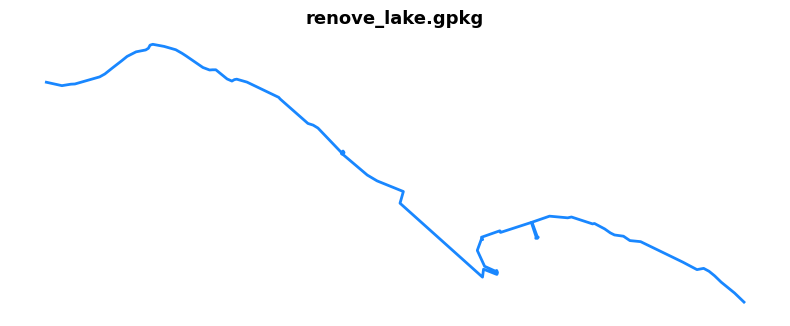

In [33]:
loaded_layers = {}

def plot_layer(gdf, title):
    geom_types = set(gdf.geom_type.unique())
    fig, ax = plt.subplots(figsize=(8, 8))

    if geom_types & {"Polygon", "MultiPolygon"}:
        gdf.plot(
            ax=ax,
            facecolor=COLORS["polygon"],
            edgecolor="white",
            alpha=0.75,
            linewidth=0.4,
        )
    else:
        gdf.plot(
            ax=ax,
            color=COLORS["line"],
            linewidth=2.0,
            alpha=0.9,
        )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_axis_off()
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()


for path in lake_files:
    try:
        gdf = load_layer(path)
    except Exception as exc:
        print("FAILED:", path.name)
        print(exc)
        continue

    map_key = infer_map_key(path.name)
    kind = layer_kind(path)
    key = (map_key, kind, path.name)
    loaded_layers[key] = gdf

    print("\n" + "=" * 80)
    print(path.name)
    print("Rows:", len(gdf))
    print("Geometry types:")
    print(gdf.geom_type.value_counts())
    display(gdf.head())

    plot_layer(gdf, path.name)

## 4. Direct area from true polygon layers

In [34]:
polygon_area_rows = []

for (map_key, kind, filename), gdf in loaded_layers.items():
    if not set(gdf.geom_type.unique()) & {"Polygon", "MultiPolygon"}:
        continue

    area_m2 = gdf.geometry.area.sum()
    polygon_area_rows.append({
        "map_key": map_key,
        "map_label": label_for_map(map_key),
        "source_file": filename,
        "kind": kind,
        "feature_count": len(gdf),
        "area_m2": area_m2,
        "area_ha": area_m2 / 10_000,
        "method": "true_polygon",
    })

polygon_area_df = pd.DataFrame(polygon_area_rows)

if polygon_area_df.empty:
    print("No true polygon layers loaded.")
else:
    polygon_area_df = polygon_area_df.sort_values("map_key", key=lambda s: s.map(sort_key_for_map))
    display(polygon_area_df)

is_save_table(polygon_area_df, OUTPUT_ROOT / "tables" / "true_polygon_area_by_map.csv")

,map_key,map_label,source_file,kind,feature_count,area_m2,area_ha,method
4,melotte,Melotte (1721),melotte_area_lake_polygon.shp,polygon_shp,1,1.318230e+06,131.823039,true_polygon
2,berney,Berney (1831),berney_area_lake_polygon.shp,polygon_shp,1,1.375956e+06,137.595631,true_polygon
5,renove,Rénové (1888),renove_area_lake_polygon.shp,polygon_shp,1,1.310513e+06,131.051327,true_polygon
0,1937,1937,1937_area_lake_polygon.shp,polygon_shp,1,1.167445e+06,116.744542,true_polygon
1,1959,1959,1959_area_lake_polygon.shp,polygon_shp,1,1.175391e+06,117.539055,true_polygon
3,contemporain,Contemporary (2021),contemporain_area_lake_polygon.shp,polygon_shp,1,9.374009e+05,93.740087,true_polygon


Saved: ../../stat_analysis/output/lake_area_analysis/tables/true_polygon_area_by_map.csv


## 5. Try polygonizing line layers

In [35]:
polygonized_rows = []
polygonized_layers = {}

for (map_key, kind, filename), gdf in loaded_layers.items():
    geom_types = set(gdf.geom_type.unique())

    if geom_types & {"Polygon", "MultiPolygon"}:
        continue
    if not geom_types & {"LineString", "MultiLineString"}:
        continue

    poly = polygonize_line_layer(gdf)
    polygonized_layers[(map_key, kind, filename)] = poly

    polygonized_rows.append({
        "map_key": map_key,
        "map_label": label_for_map(map_key),
        "source_file": filename,
        "kind": kind,
        "line_feature_count": len(gdf),
        "polygon_count": len(poly),
        "area_m2": poly.geometry.area.sum() if not poly.empty else 0,
        "area_ha": poly.geometry.area.sum() / 10_000 if not poly.empty else 0,
        "polygonized": not poly.empty,
        "method": "polygonized_lines",
    })

polygonized_df = pd.DataFrame(polygonized_rows)

if polygonized_df.empty:
    print("No line layers available for polygonizing.")
else:
    polygonized_df = polygonized_df.sort_values("map_key", key=lambda s: s.map(sort_key_for_map))
    display(polygonized_df)

is_save_table(polygonized_df, OUTPUT_ROOT / "tables" / "polygonized_area_by_map.csv")

,map_key,map_label,source_file,kind,line_feature_count,polygon_count,area_m2,area_ha,polygonized,method
8,melotte,Melotte (1721),melotte_area_lake.gpkg,area_lake,2,0,0.000000e+00,0.000000,False,polygonized_lines
9,melotte,Melotte (1721),melotte_lake.gpkg,lake,2,0,0.000000e+00,0.000000,False,polygonized_lines
4,berney,Berney (1831),berney_area_lake.gpkg,area_lake,1,1,1.363561e-02,0.000001,True,polygonized_lines
5,berney,Berney (1831),berney_lake.gpkg,lake,1,1,1.363561e-02,0.000001,True,polygonized_lines
10,renove,Rénové (1888),renove_area_lake.gpkg,area_lake,1,1,1.310513e+06,131.051327,True,polygonized_lines
11,renove,Rénové (1888),renove_lake.gpkg,lake,1,0,0.000000e+00,0.000000,False,polygonized_lines
0,1937,1937,1937_area_lake.gpkg,area_lake,3,0,0.000000e+00,0.000000,False,polygonized_lines
1,1937,1937,1937_lake.gpkg,lake,3,0,0.000000e+00,0.000000,False,polygonized_lines
2,1959,1959,1959_area_lake.gpkg,area_lake,3,0,0.000000e+00,0.000000,False,polygonized_lines
3,1959,1959,1959_lake.gpkg,lake,3,0,0.000000e+00,0.000000,False,polygonized_lines


Saved: ../../stat_analysis/output/lake_area_analysis/tables/polygonized_area_by_map.csv


## 6. Plot polygonized results


1937_area_lake.gpkg
No polygons created.

1937_lake.gpkg
No polygons created.

1959_area_lake.gpkg
No polygons created.

1959_lake.gpkg
No polygons created.

berney_area_lake.gpkg


,geometry,area_m2,area_ha
0,"POLYGON ((2537039.753 1151394.411, 2537039.575 1151394.486, 2537039.937 1151394.486, 2537039.753 1151394.411))",0.013636,0.000001


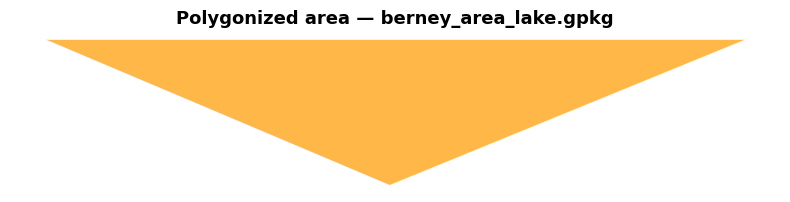


berney_lake.gpkg


,geometry,area_m2,area_ha
0,"POLYGON ((2537039.753 1151394.411, 2537039.575 1151394.486, 2537039.937 1151394.486, 2537039.753 1151394.411))",0.013636,0.000001


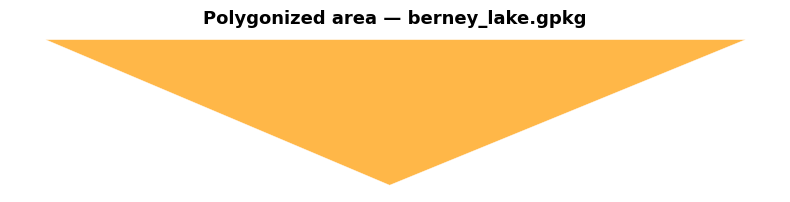


contemporain_area_lake.gpkg


geometry  \
0  POLYGON ((2538882.687 1150699.266, 2538875.09 1150198.265, 2535790.068 1151408.907, 2535854.432 1151485.095, 2536079.618 1151406.381, 2536295.397 1151424.898, 2536301.538 1151422.064, 2536306.923 1151435.196, 2536302.01 1151437.841, 2536294.641 1151431.795, 2536080.374 1151414.978, 2535996.67 1151444.643, 2535994.969 1151450.689, 2535998.37 1151468.073, 2536031.342 1151463.916, 2536032.948 1151474.875, 2535998.37 1151479.032, 2536015.754 1151585.032, 2536225.486 1151589.188, 2536227.753 1151577.852, 2536222.841 1151577.285, 2536232.194 1151528.819, 2536237.579 1151529.481, 2536239.657 1151517.199, 2536234.367 1151516.16, 2536239.752 1151489.707, 2536261.103 1151489.518, 2536281.887 1151520.6, 2536308.529 1151495.376, 2536323.739 1151473.741, 2536322.369 1151466.514, 2536327.943 1151462.877, 2536332.62 1151463.963, 2536337.343 1151469.631, 2536353.593 1151469.679, 2536369.89 1151465.38, 2536383.824 1151456.877, 2536386.47 1151462.64, 2536393.225 1151462.971, 2536400.31 1151461.648, 2536411.553 1151455.791, 2536427.613 1151443.037, 2536429.786 1151449.272, 2536436.683 1151450.406, 2536451.326 1151449.083, 2536463.891 1151442.848, 2536477.779 1151432.456, 2536486.66 1151436.329, 2536497.855 1151435.621, 2536511.884 1151429.669, 2536526.622 1151420.41, 2536528.7 1151425.607, 2536541.549 1151426.74, 2536556.192 1151421.733, 2536571.025 1151410.302, 2536572.725 1151415.12, 2536579.811 1151415.592, 2536601.54 1151408.885, 2536616.939 1151396.603, 2536620.34 1151403.405, 2536629.504 1151402.177, 2536637.535 1151399.437, 2536645.659 1151394.525, 2536660.397 1151384.699, 2536666.444 1151375.819, 2536669.089 1151381.487, 2536672.49 1151382.432, 2536679.859 1151381.676, 2536689.495 1151376.952, 2536708.579 1151361.27, 2536715.287 1151350.783, 2536723.884 1151357.113, 2536734.654 1151351.161, 2536737.866 1151348.705, 2536747.786 1151340.863, 2536754.21 1151333.872, 2536760.445 1151325.086, 2536762.051 1151325.086, 2536765.264 1151328.582, 2536769.704 1151328.298, 2536782.883 1151320.173, 2536792.708 1151311.198, 2536808.391 1151290.32, 2536810.375 1151293.059, 2536819.917 1151290.509, 2536839.709 1151273.551, 2536854.636 1151254.183, 2536824.782 1151197.31, 2536886.852 1151155.93, 2536961.392 1151077.328, 2537031.586 1151003.26, 2537067.108 1150969.061, 2537115.003 1150929.668, 2537135.672 1150921.98, 2537093.75 1150955.362, 2537059.739 1150985.594, 2537018.171 1151027.729, 2537017.037 1151029.335, 2537024.5 1151036.893, 2536966.399 1151097.829, 2536997.008 1151132.595, 2536993.418 1151136.28, 2537007.401 1151152.151, 2537011.746 1151148.467, 2537052.654 1151193.153, 2537117.935 1151140.72, 2537125.493 1151150.073, 2537259.457 1151030.091, 2537237.917 1151005.339, 2537245.003 1151007.228, 2537249.065 1150994.663, 2537240.752 1150992.112, 2537248.404 1150969.533, 2537238.39 1150966.274, 2537239.523 1150962.542, 2537241.744 1150960.322, 2537266.165 1150969.958, 2537273.251 1150947.662, 2537276.321 1150946.103, 2537281.234 1150947.237, 2537282.084 1150950.119, 2537275.66 1150968.824, 2537273.298 1150972.414, 2537272.211 1150976.146, 2537305.325 1150987.341, 2537303.813 1150991.498, 2537335.722 1151002.245, 2537337.28 1150998.56, 2537428.637 1151036.303, 2537617.774 1150866.674, 2537613.428 1150854.015, 2537619.097 1150852.125, 2537598.596 1150771.067, 2537580.551 1150775.601, 2537576.961 1150780.231, 2537572.426 1150778.152, 2537594.226 1150751.417, 2537619.775 1150741.913, 2537642.999 1150831.436, 2537653.863 1150828.743, 2537675.403 1150808.006, 2537675.923 1150800.873, 2537679.607 1150798.7, 2537683.197 1150801.109, 2537725.569 1150763.461, 2537710.411 1150708.2, 2537746.543 1150694.761, 2537764.776 1150705.643, 2537778.474 1150713.674, 2537827.034 1150735.403, 2537859.533 1150748.44, 2537861.517 1150751.652, 2537862.556 1150763.556, 2537861.328 1150765.162, 2537857.644 1150764.312, 2537852.92 1150759.21, 2537840.827 1150769.791, 2537838.371 1150770.264, 2537835.253 1150769.319, 2537786.316 1150814.95, 2537788.583 1150816.36

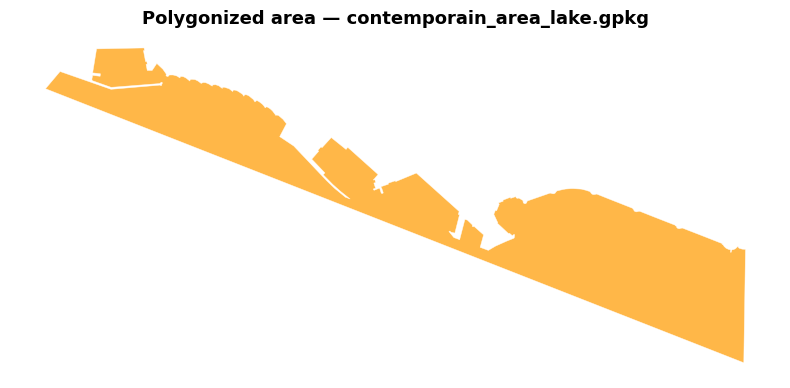


contemporain_lake.gpkg
No polygons created.

melotte_area_lake.gpkg
No polygons created.

melotte_lake.gpkg
No polygons created.

renove_area_lake.gpkg


,geometry,area_m2,area_ha
0,"POLYGON ((2535892.255 1151581.638, 2535965.792 1151565.495, 2536021.957 1151572.742, 2536129.305 1151603.543, 2536185.017 1151642.496, 2536224.877 1151673.296, 2536248.43 1151692.32, 2536287.383 1151712.249, 2536329.054 1151720.402, 2536340.83 1151727.649, 2536348.077 1151741.238, 2536359.854 1151744.861, 2536408.772 1151735.802, 2536459.502 1151721.308, 2536504.796 1151694.132, 2536577.267 1151644.308, 2536606.256 1151633.437, 2536633.433 1151634.343, 2536682.351 1151594.484, 2536703.186 1151585.425, 2536724.021 1151593.578, 2536768.41 1151580.895, 2536906.105 1151514.766, 2537032.93 1151401.529, 2537055.577 1151394.282, 2537076.412 1151381.6, 2537176.966 1151276.517, 2537185.119 1151281.952, 2537187.837 1151278.328, 2537189.649 1151274.705, 2537184.213 1151277.423, 2537178.778 1151269.27, 2537182.401 1151267.458, 2537184.213 1151267.458, 2537290.202 1151177.775, 2537332.779 1151152.41, 2537446.921 1151106.209, 2537432.427 1151055.48, 2537790.253 1150734.795, 2537794.783 1150769.219, 2537852.759 1150746.571, 2537855.477 1150754.724, 2537851.854 1150763.783, 2537849.136 1150759.254, 2537799.312 1150781.901, 2537767.606 1150850.749, 2537784.818 1150897.855, 2537791.159 1150897.855, 2537785.724 1150907.82, 2537865.442 1150935.902, 2537868.16 1150928.655, 2538002.231 1150972.138, 2538023.067 1150908.726, 2538021.255 1150903.29, 2538028.502 1150903.29, 2538032.126 1150907.82, 2538027.596 1150910.537, 2538004.949 1150973.044, 2538081.044 1150999.315, 2538159.856 1150992.067, 2538176.162 1150995.691, 2538267.657 1150965.797, 2538275.81 1150967.608, 2538362.775 1150917.785, 2538401.728 1150912.349, 2538429.811 1150893.326, 2538476.011 1150888.796, 2538720.601 1150767.407, 2538749.59 1150772.842, 2538773.143 1150760.16, 2538825.684 1150713.054, 2538883.661 1150665.947, 2538929.024 1150622.329, 2538875.761 1150198.455, 2535789.735 1151408.667, 2535892.255 1151581.638))",1.310513e+06,131.051327


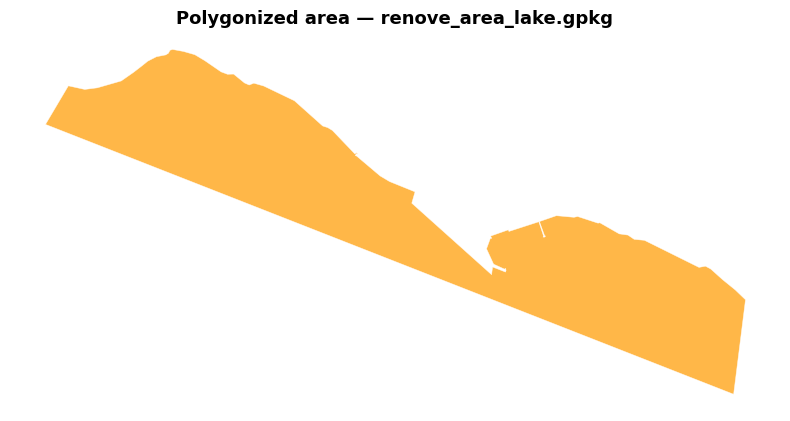


renove_lake.gpkg
No polygons created.


In [36]:
for (map_key, kind, filename), poly in polygonized_layers.items():
    print("\n" + "=" * 80)
    print(filename)

    if poly.empty:
        print("No polygons created.")
        continue

    display(poly.sort_values("area_ha", ascending=False).head())

    fig, ax = plt.subplots(figsize=(8, 8))
    poly.plot(
        ax=ax,
        facecolor=COLORS["polygonized"],
        edgecolor="white",
        linewidth=0.4,
        alpha=0.75,
    )

    ax.set_title(f"Polygonized area — {filename}", fontsize=13, fontweight="bold")
    ax.set_axis_off()
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

## 7. Select best available area source per map

In [37]:
candidate_parts = []

if not polygon_area_df.empty:
    tmp = polygon_area_df.copy()
    tmp["priority"] = 1
    candidate_parts.append(tmp)

if not polygonized_df.empty:
    tmp = polygonized_df[polygonized_df["polygonized"]].copy()
    tmp["priority"] = np.where(tmp["kind"].eq("area_lake"), 2, 3)
    tmp = tmp.rename(columns={"polygon_count": "feature_count"})
    tmp = tmp[[
        "map_key", "map_label", "source_file", "kind",
        "feature_count", "area_m2", "area_ha", "method", "priority"
    ]]
    candidate_parts.append(tmp)

if candidate_parts:
    area_candidates = pd.concat(candidate_parts, ignore_index=True)
    area_candidates = area_candidates.sort_values(
        ["map_key", "priority"],
        key=lambda s: s.map(sort_key_for_map) if s.name == "map_key" else s
    )

    best_area = (
        area_candidates
        .sort_values(["map_key", "priority"], key=lambda s: s.map(sort_key_for_map) if s.name == "map_key" else s)
        .groupby("map_key", as_index=False)
        .first()
        .sort_values("map_key", key=lambda s: s.map(sort_key_for_map))
    )
else:
    area_candidates = pd.DataFrame()
    best_area = pd.DataFrame()

print("All candidates:")
display(area_candidates)

print("Best source per map:")
display(best_area)

is_save_table(area_candidates, OUTPUT_ROOT / "tables" / "lake_area_candidates.csv")
is_save_table(best_area, OUTPUT_ROOT / "tables" / "lake_area_best_source_by_map.csv")

All candidates:


,map_key,map_label,source_file,kind,feature_count,area_m2,area_ha,method,priority
0,melotte,Melotte (1721),melotte_area_lake_polygon.shp,polygon_shp,1,1.318230e+06,131.823039,true_polygon,1
1,berney,Berney (1831),berney_area_lake_polygon.shp,polygon_shp,1,1.375956e+06,137.595631,true_polygon,1
6,berney,Berney (1831),berney_area_lake.gpkg,area_lake,1,1.363561e-02,0.000001,polygonized_lines,2
7,berney,Berney (1831),berney_lake.gpkg,lake,1,1.363561e-02,0.000001,polygonized_lines,3
2,renove,Rénové (1888),renove_area_lake_polygon.shp,polygon_shp,1,1.310513e+06,131.051327,true_polygon,1
8,renove,Rénové (1888),renove_area_lake.gpkg,area_lake,1,1.310513e+06,131.051327,polygonized_lines,2
3,1937,1937,1937_area_lake_polygon.shp,polygon_shp,1,1.167445e+06,116.744542,true_polygon,1
4,1959,1959,1959_area_lake_polygon.shp,polygon_shp,1,1.175391e+06,117.539055,true_polygon,1
5,contemporain,Contemporary (2021),contemporain_area_lake_polygon.shp,polygon_shp,1,9.374009e+05,93.740087,true_polygon,1
9,contemporain,Contemporary (2021),contemporain_area_lake.gpkg,area_lake,1,9.374009e+05,93.740087,polygonized_lines,2


Best source per map:


,map_key,map_label,source_file,kind,feature_count,area_m2,area_ha,method,priority
4,melotte,Melotte (1721),melotte_area_lake_polygon.shp,polygon_shp,1,1.318230e+06,131.823039,true_polygon,1
2,berney,Berney (1831),berney_area_lake_polygon.shp,polygon_shp,1,1.375956e+06,137.595631,true_polygon,1
5,renove,Rénové (1888),renove_area_lake_polygon.shp,polygon_shp,1,1.310513e+06,131.051327,true_polygon,1
0,1937,1937,1937_area_lake_polygon.shp,polygon_shp,1,1.167445e+06,116.744542,true_polygon,1
1,1959,1959,1959_area_lake_polygon.shp,polygon_shp,1,1.175391e+06,117.539055,true_polygon,1
3,contemporain,Contemporary (2021),contemporain_area_lake_polygon.shp,polygon_shp,1,9.374009e+05,93.740087,true_polygon,1


Saved: ../../stat_analysis/output/lake_area_analysis/tables/lake_area_candidates.csv
Saved: ../../stat_analysis/output/lake_area_analysis/tables/lake_area_best_source_by_map.csv


## 8. Plot selected area over time

Saved: ../../stat_analysis/output/lake_area_analysis/figures/lake_area_over_time.png


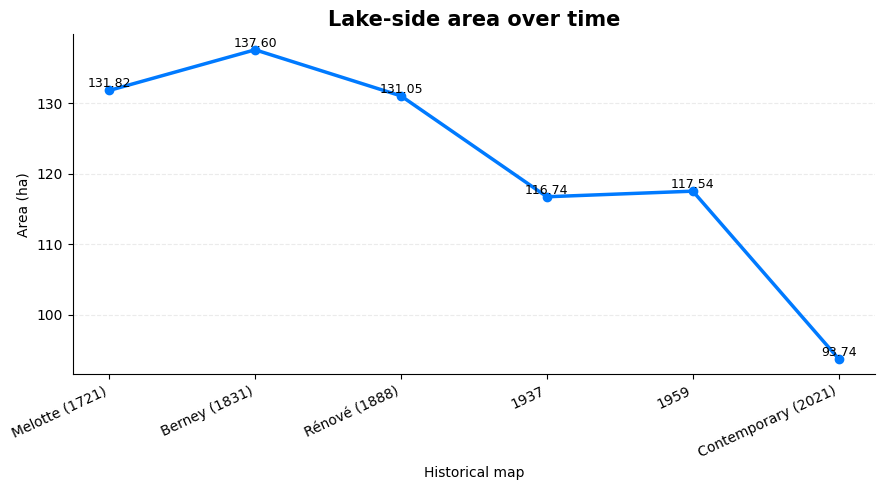

In [38]:
if best_area.empty:
    print("No usable area data available.")
else:
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(
        best_area["map_label"],
        best_area["area_ha"],
        color="#007AFF",
        marker="o",
        linewidth=2.5,
    )

    ax.set_title("Lake-side area over time", fontsize=15, fontweight="bold")
    ax.set_xlabel("Historical map")
    ax.set_ylabel("Area (ha)")
    ax.grid(axis="y", linestyle="--", alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for x, y in zip(best_area["map_label"], best_area["area_ha"]):
        ax.text(x, y, f"{y:.2f}", ha="center", va="bottom", fontsize=9)

    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    is_savefig(OUTPUT_ROOT / "figures" / "lake_area_over_time.png")
    plt.show()

## 9. Overlay selected lake boundaries

Loaded: melotte_area_lake_polygon.shp
Loaded: berney_area_lake_polygon.shp
Loaded: renove_area_lake_polygon.shp
Loaded: 1937_area_lake_polygon.shp
Loaded: 1959_area_lake_polygon.shp
Loaded: contemporain_area_lake_polygon.shp
Saved: ../../stat_analysis/output/lake_area_analysis/figures/lake_area_boundary_overlay.png


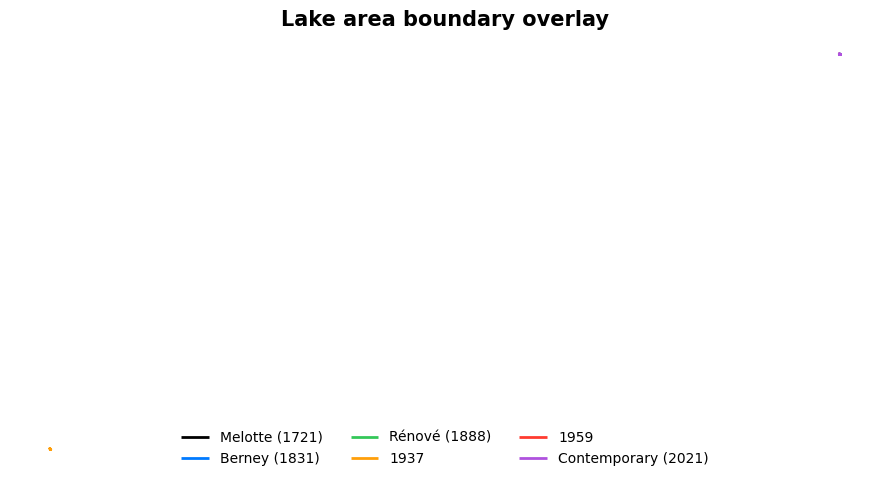

In [42]:
best_geoms = {}

LAKE_COLORS = {
    "melotte": "#000000",
    "berney": "#007AFF",
    "renove": "#34C759",
    "1937": "#FF9F0A",
    "1959": "#FF3B30",
    "contemporain": "#AF52DE",
}

for _, row in best_area.iterrows():
    path = DATA_DIR / row["source_file"]

    try:
        gdf = load_layer(path)
        best_geoms[row["map_key"]] = gdf.geometry.union_all()
        print("Loaded:", row["source_file"])
    except Exception as exc:
        print("Failed:", row["source_file"], exc)

if not best_geoms:
    print("No selected polygon geometries available for overlay.")
else:
    fig, ax = plt.subplots(figsize=(9, 8))

    for map_key in sorted(best_geoms.keys(), key=sort_key_for_map):
        gpd.GeoSeries(
            [best_geoms[map_key]],
            crs=f"EPSG:{TARGET_EPSG}"
        ).boundary.plot(
            ax=ax,
            linewidth=2,
            color=LAKE_COLORS.get(map_key, "#8E8E93"),
            label=label_for_map(map_key),
        )

    ax.set_title("Lake area boundary overlay", fontsize=15, fontweight="bold")
    ax.set_axis_off()
    ax.set_aspect("equal")

    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=3,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    is_savefig(OUTPUT_ROOT / "figures" / "lake_area_boundary_overlay.png")
    plt.show()

## Interpretation notes

- If `*_area_lake_polygon.shp` loads, it is the preferred source for area.
- If it fails, check whether `.shx`, `.dbf`, and `.prj` exist.
- `.gpkg` lake files may contain lines, not polygons.
- Lines can only be converted to area if they form closed boundaries.
- Use area results only for years where a reliable polygon exists or polygonization clearly works.

## Save outputs

At the top, change:

```python
SAVE_OUTPUTS = True
```